In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import sys
sys.path.append("../")
from src.data.load_data import load_dataset
from src.data.preprocess import  replace_outliers_iqr
from src.visualizations.code_plots.statistic import plot_correlation_coefficients 
from src.visualizations.code_plots.Visualize_prepro import plot_box_plot, plot_all_distributions,plot_correlation_heatmap
#plt.style.use('ggplot')
import seaborn as sns
sns.set_style("whitegrid")
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns


# Importation des jeux de données

In [161]:
# Air Quality
df1 = load_dataset("../data/Unzip/air+quality/AirQualityUCI.xlsx", file_format="excel")

Dataset successfully loaded. Dimensions: (9357, 15)


In [162]:
df1.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [163]:
df2 = load_dataset("../data/Unzip/hcv+data/hcvdat_test.csv")

Dataset successfully loaded. Dimensions: (615, 12)


In [164]:
df2.head()

,Unnamed: 0,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0,32.0,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,1,32.0,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,2,32.0,46.9,74.7,36.2,25.9,6.1,8.84,5.20,86.0,33.2,79.3
3,3,32.0,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,4,32.0,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [165]:
df2.columns

Index(['Unnamed: 0', 'Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL',
       'CREA', 'GGT', 'PROT'],
      dtype='object')

In [166]:
df2 = df2.drop('Unnamed: 0', axis=1)

In [167]:
df3 = load_dataset("../data/Unzip/c2k.csv")

Dataset successfully loaded. Dimensions: (3943, 98)


In [168]:
df3.head()

,nr,i1_legid,i1_rcs_p,i1_rcs_e,i1_dep_1_p,i1_dep_1_e,i1_dep_1_place,i1_rcf_1_p,i1_rcf_1_e,i1_rcf_1_place,...,o_dep_3_p,o_dep_3_e,o_dep_3_place,o_rcf_3_p,o_rcf_3_e,o_rcf_3_place,o_dlv_p,o_dlv_e,o_hops,legs
0,0.0,5182.0,199.0,218.0,210.0,215.0,609.0,935.0,736.0,256.0,...,?,?,?,?,?,?,780.0,434.0,1.0,2.0
1,1.0,6523.0,844.0,584.0,90.0,297.0,700.0,1935.0,1415.0,431.0,...,?,?,?,?,?,?,3870.0,445.0,1.0,2.0
2,2.0,5878.0,4380.0,4119.0,90.0,280.0,456.0,905.0,547.0,700.0,...,?,?,?,?,?,?,550.0,1520.0,1.0,1.0
3,3.0,1275.0,759.0,169.0,240.0,777.0,173.0,340.0,577.0,349.0,...,?,?,?,?,?,?,3780.0,159.0,1.0,1.0
4,4.0,8117.0,1597.0,1485.0,150.0,241.0,411.0,585.0,612.0,128.0,...,?,?,?,?,?,?,4140.0,4797.0,2.0,1.0


In [169]:
df4 = load_dataset("../data/Unzip/hungary_chickenpox.csv")

Dataset successfully loaded. Dimensions: (522, 21)


In [170]:
df4.head()

,Date,BUDAPEST,BARANYA,BACS,BEKES,BORSOD,CSONGRAD,FEJER,GYOR,HAJDU,...,JASZ,KOMAROM,NOGRAD,PEST,SOMOGY,SZABOLCS,TOLNA,VAS,VESZPREM,ZALA
0,03/01/2005,168,79,30,173,169,42,136,120,162,...,130,57,2,178,66,64,11,29,87,68
1,10/01/2005,157,60,30,92,200,53,51,70,84,...,80,50,29,141,48,29,58,53,68,26
2,17/01/2005,96,44,31,86,93,30,93,84,191,...,64,46,4,157,33,33,24,18,62,44
3,24/01/2005,163,49,43,126,46,39,52,114,107,...,63,54,14,107,66,50,25,21,43,31
4,31/01/2005,122,78,53,87,103,34,95,131,172,...,61,49,11,124,63,56,7,47,85,60


In [171]:
df = [df1, df2, df3, df4]

In [172]:

def plot_multiple_heatmaps(dfs):
    n = len(dfs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    for i, df in enumerate(dfs):
        ax = axes[i] if n > 1 else axes
        sns.heatmap(df.select_dtypes(exclude ='object').isna(), ax=ax, cmap="coolwarm", annot=True)
        ax.set_title(f"Heatmap {i+1}")

    plt.tight_layout()
    plt.show()


# 1- Dataset Air quality dataset

In [173]:
df1.shape

(9357, 15)

In [174]:
df1.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [175]:
df1.isna().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

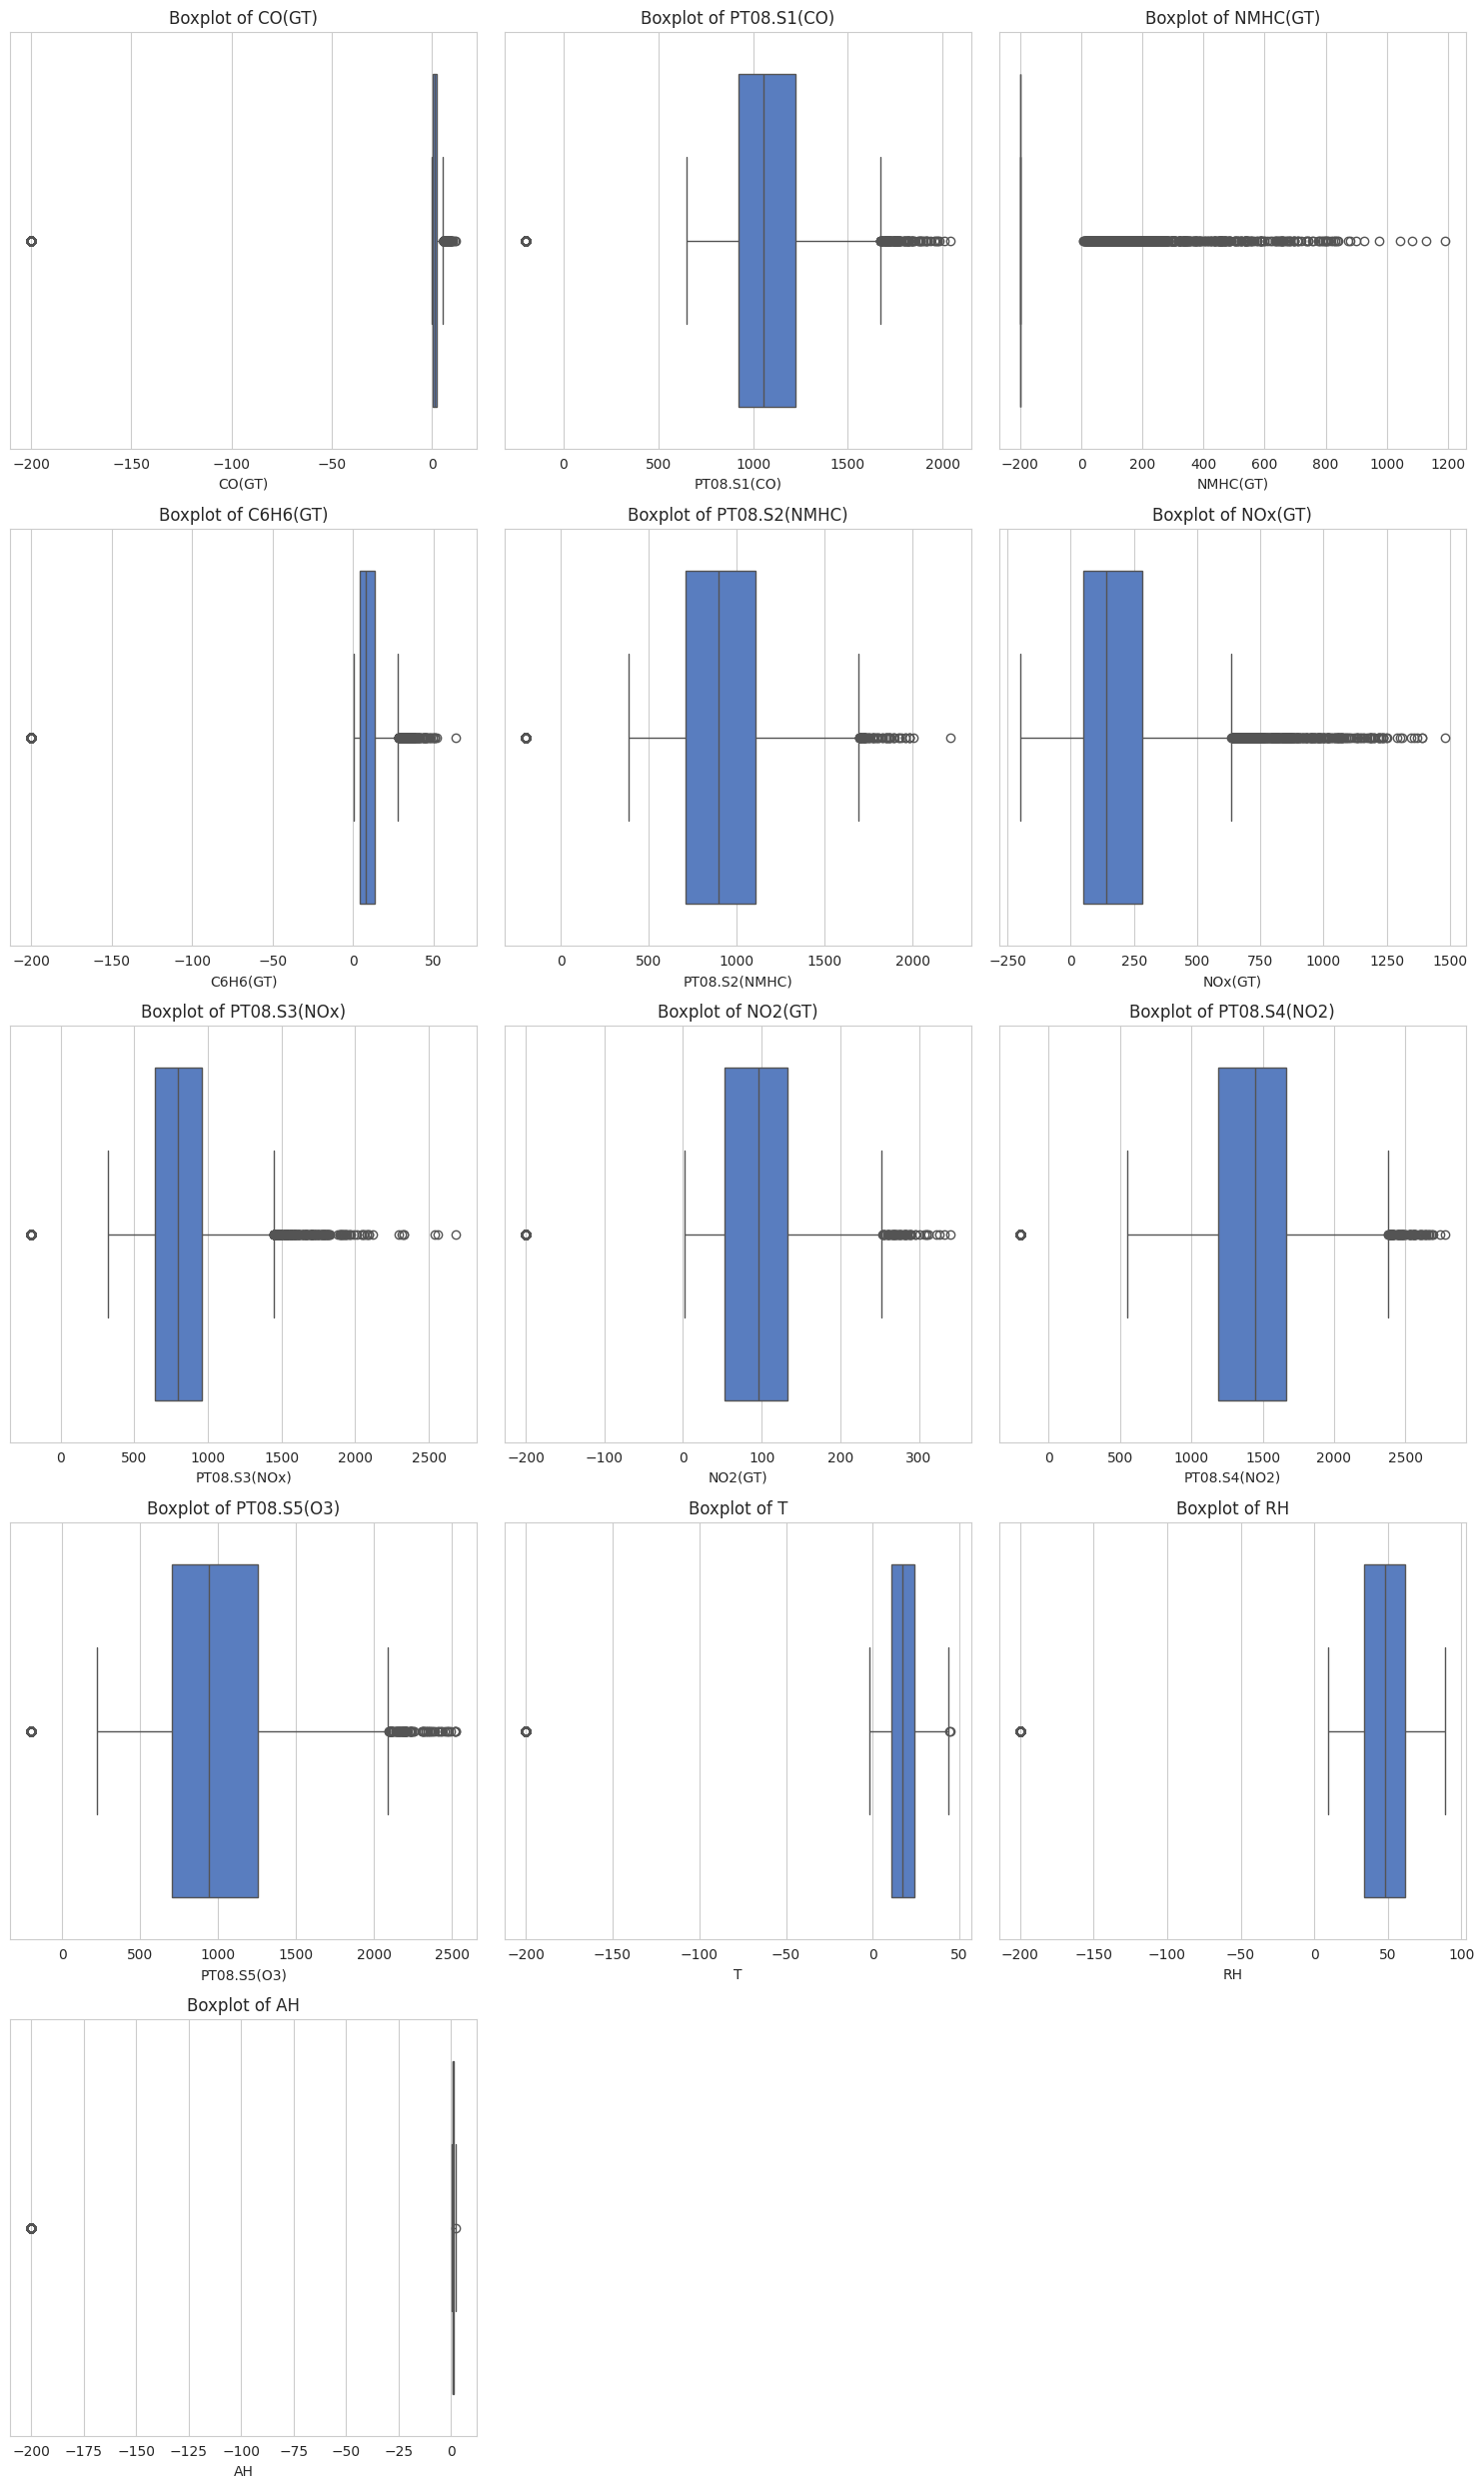

In [176]:
plot_box_plot(df1)

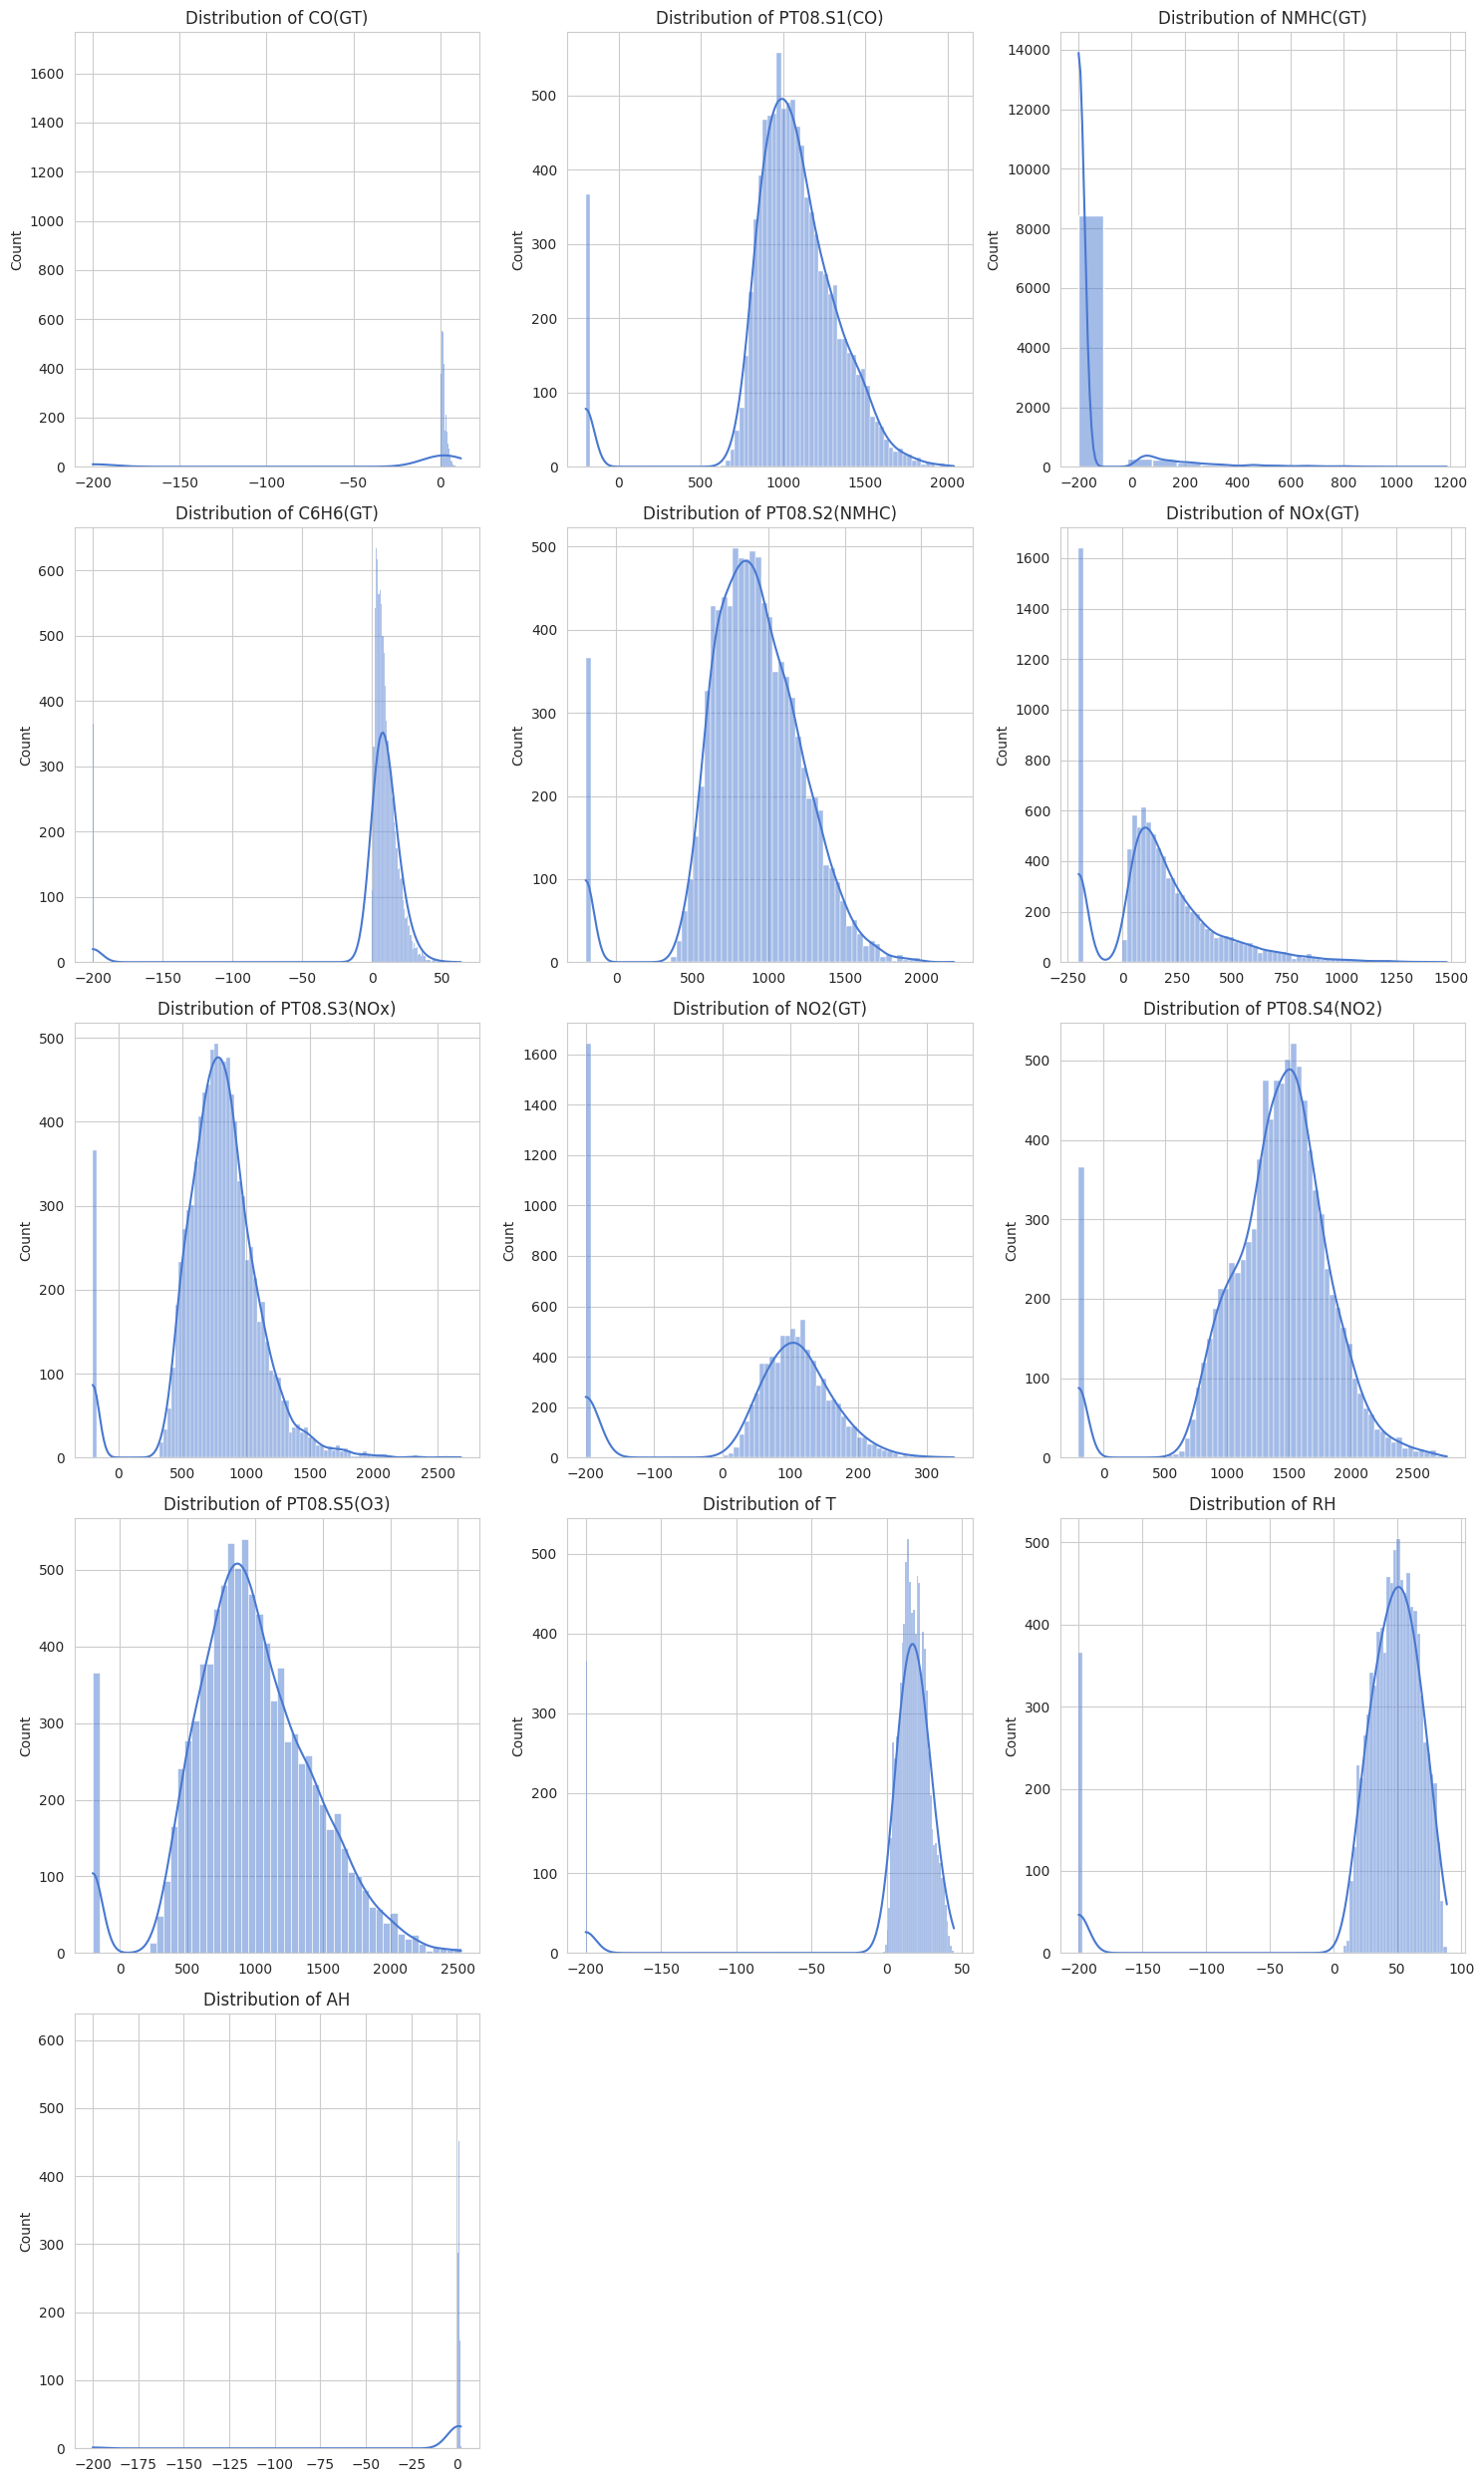

In [177]:
plot_all_distributions(df1)

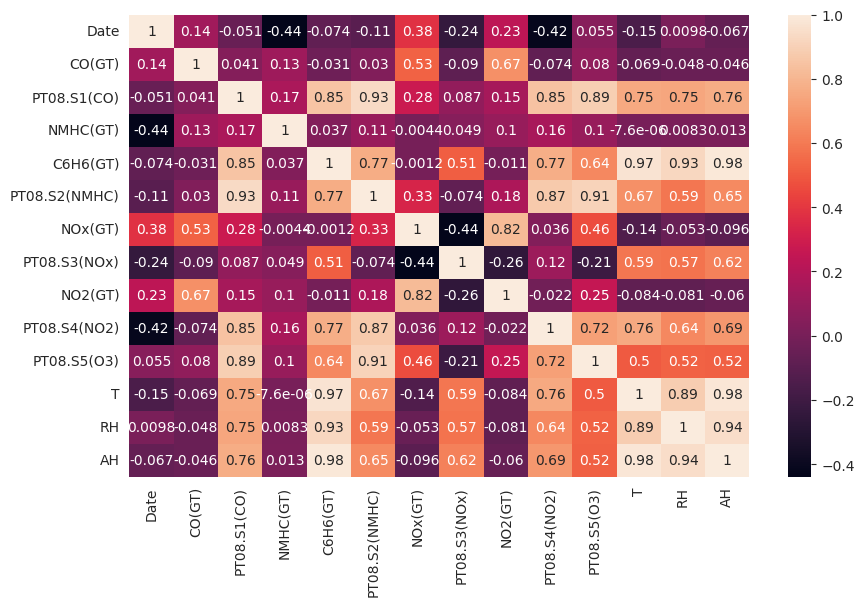

In [178]:
plt.figure(figsize=(10,6))
sns.heatmap(df1.select_dtypes(exclude=('object')).corr(), annot=True)
plt.show()


In [179]:
#sns.pairplot(df1.select_dtypes(exclude='object'))

# 2 - Dataset Hepatite C virus

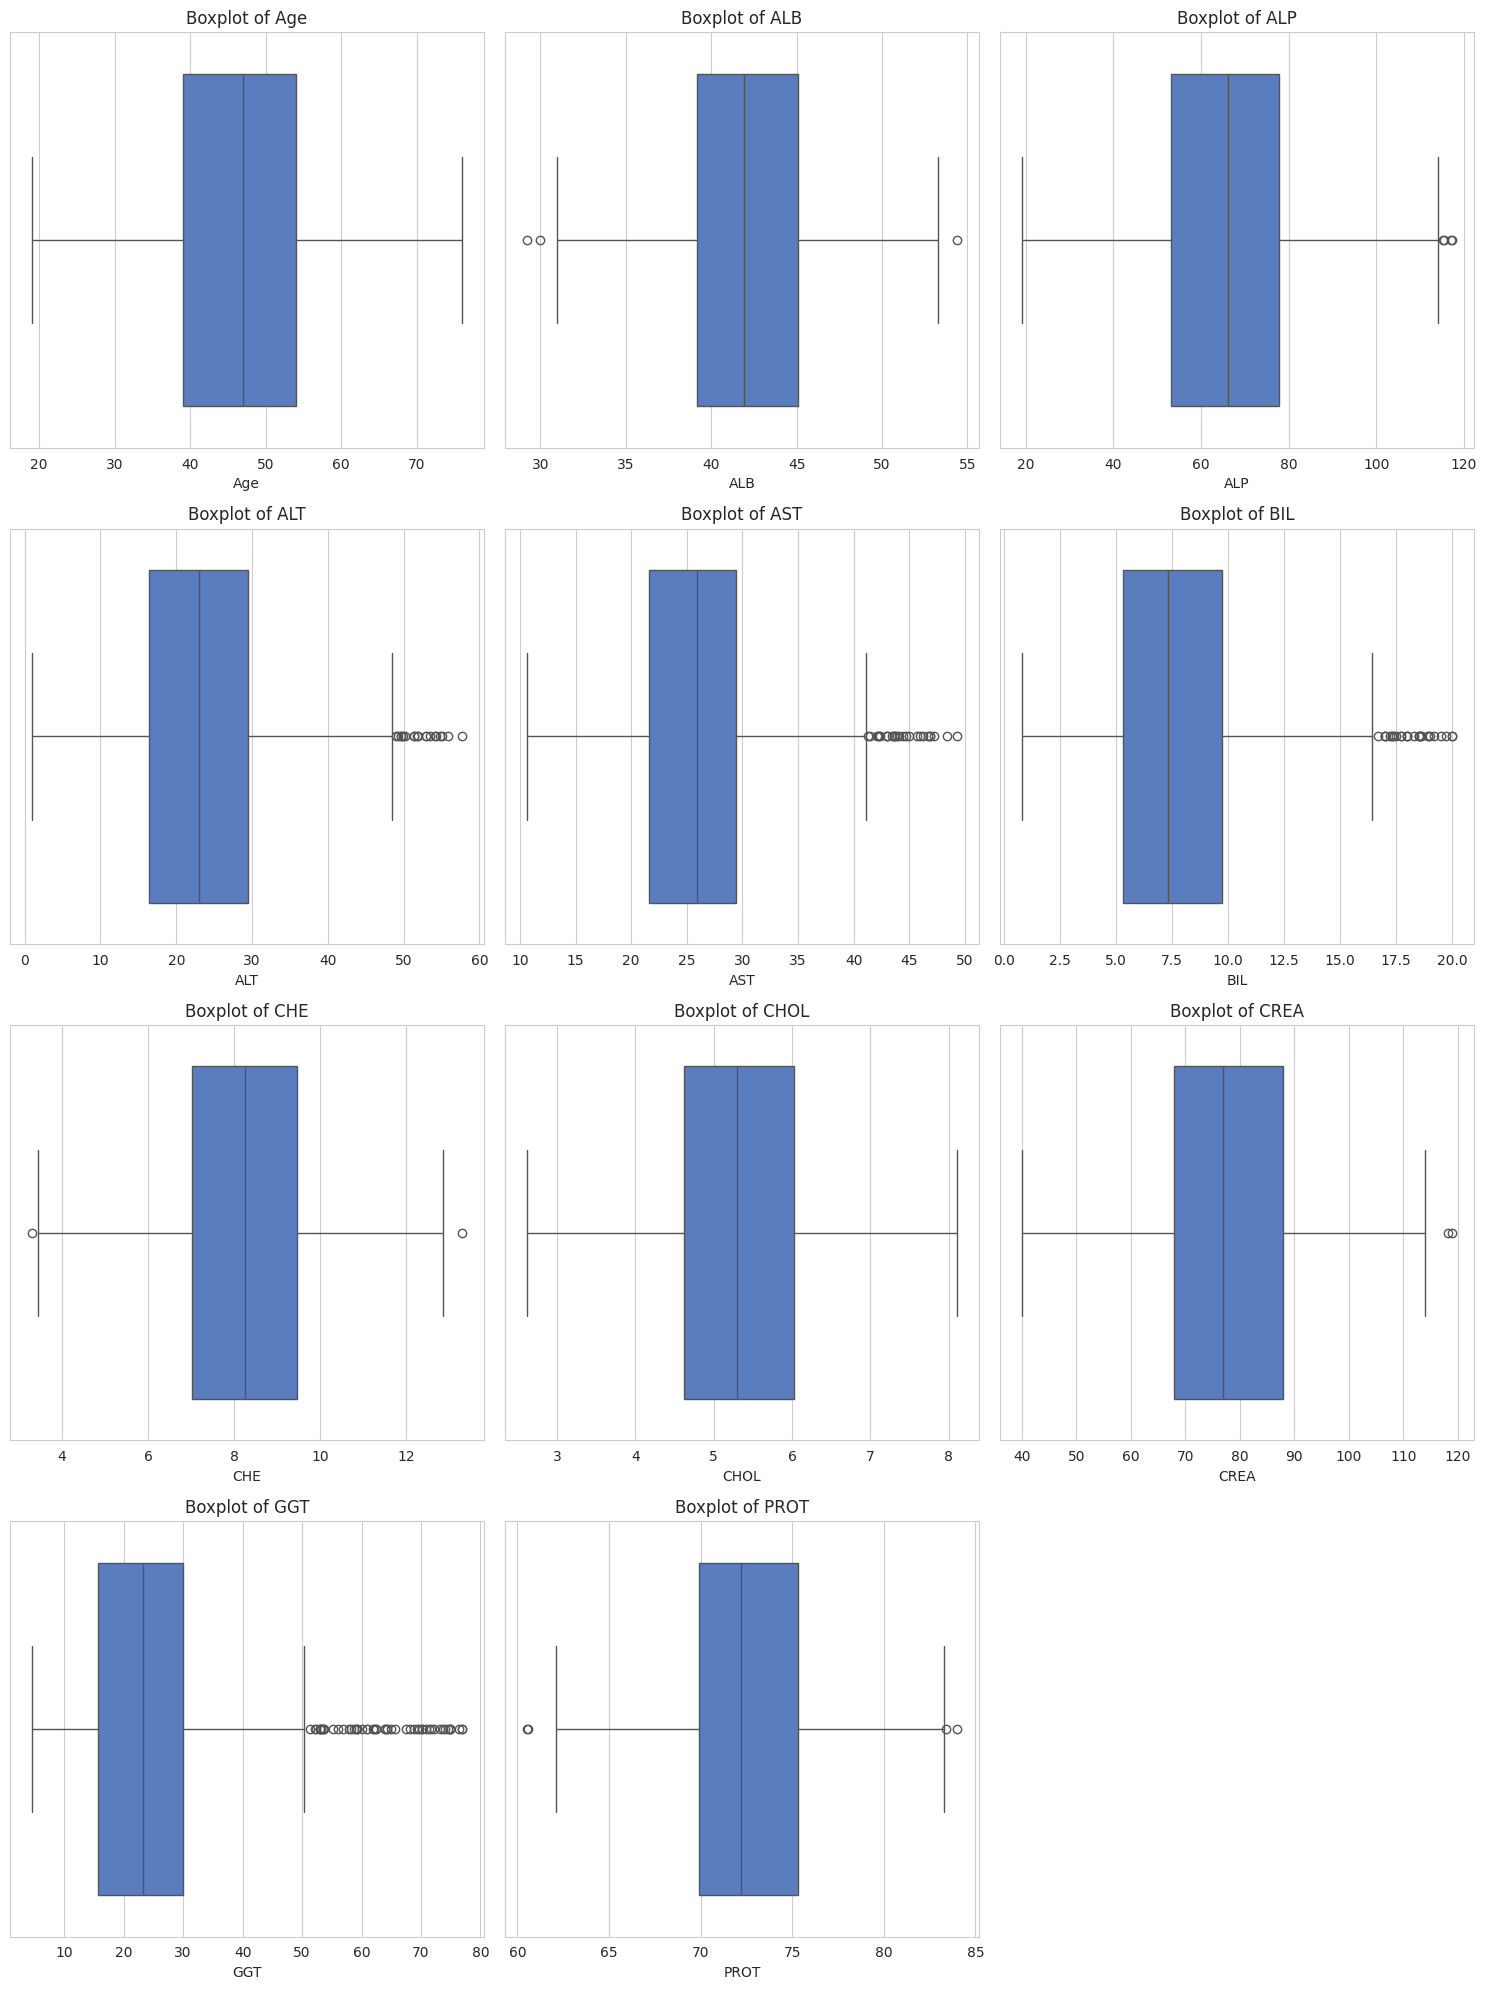

In [180]:
plot_box_plot(df2)

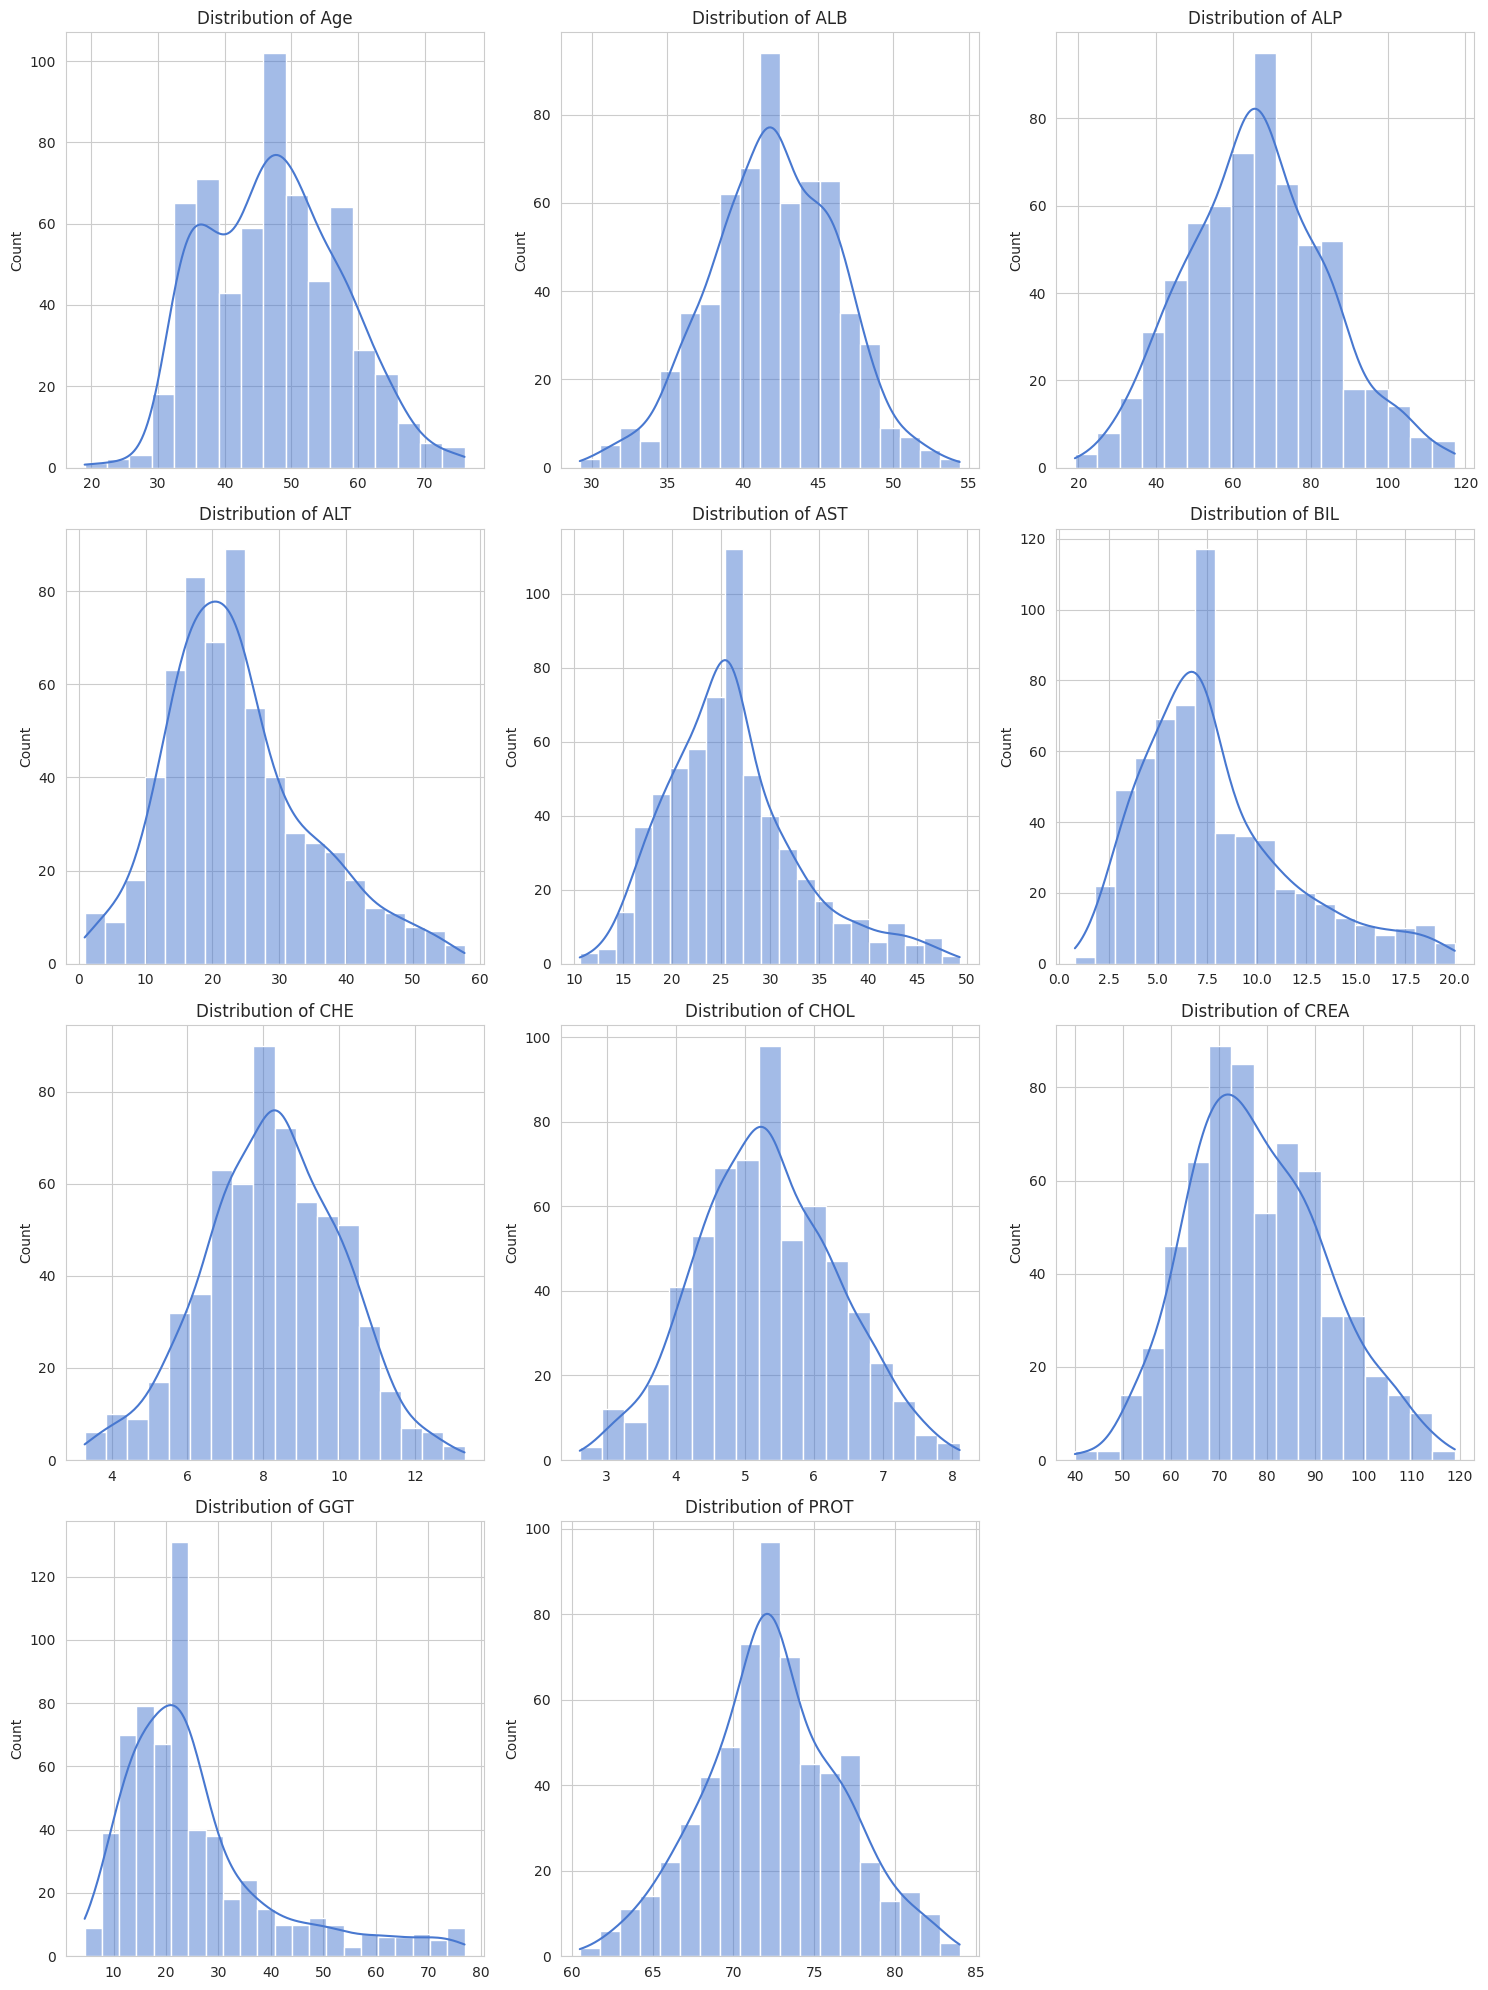

In [181]:
plot_all_distributions(df2)

In [182]:
df2.isna().sum()

Age     0
ALB     0
ALP     0
ALT     0
AST     0
BIL     0
CHE     0
CHOL    0
CREA    0
GGT     0
PROT    0
dtype: int64

In [183]:
df2.dtypes

Age     float64
ALB     float64
ALP     float64
ALT     float64
AST     float64
BIL     float64
CHE     float64
CHOL    float64
CREA    float64
GGT     float64
PROT    float64
dtype: object

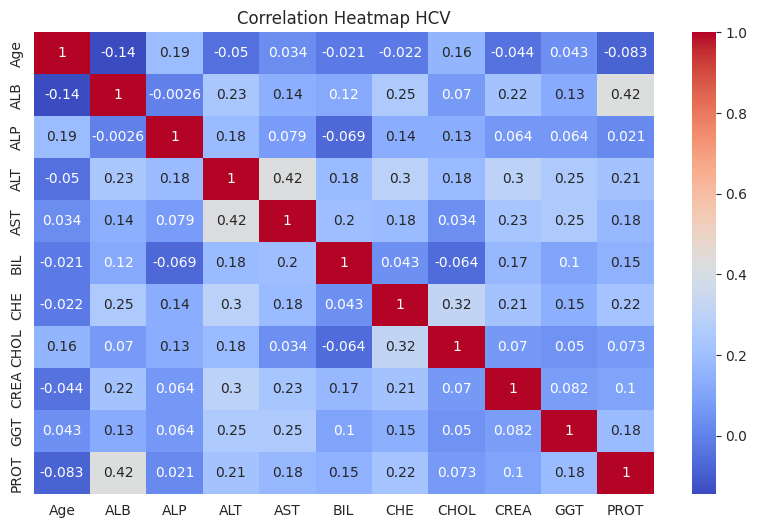

In [184]:
plot_correlation_heatmap(df2, title="Correlation Heatmap HCV")

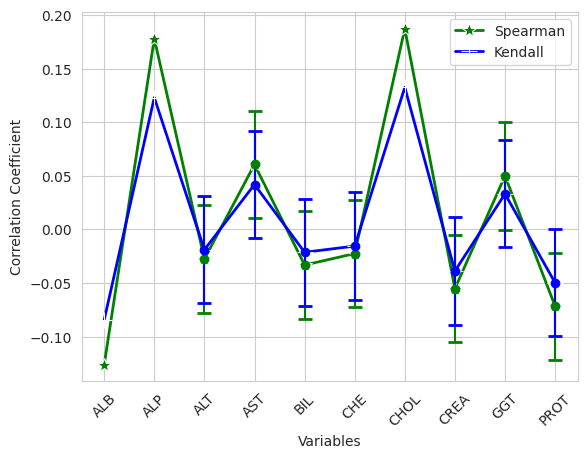

In [185]:
plot_correlation_coefficients(df2, target_column='Age')

In [186]:
#sns.pairplot(df2)

# 3 - Dataset CK2


L'ensemble de données C2K est un ensemble de données qui contient des enregistrements de Cargo 2000
suivi du fret aérien et des événements pour une durée de 5 mois. Les données C2K
l'ensemble contient 98 attributs et 3942 objets (certains avec des valeurs manquantes)

In [187]:
df3.head()

,nr,i1_legid,i1_rcs_p,i1_rcs_e,i1_dep_1_p,i1_dep_1_e,i1_dep_1_place,i1_rcf_1_p,i1_rcf_1_e,i1_rcf_1_place,...,o_dep_3_p,o_dep_3_e,o_dep_3_place,o_rcf_3_p,o_rcf_3_e,o_rcf_3_place,o_dlv_p,o_dlv_e,o_hops,legs
0,0.0,5182.0,199.0,218.0,210.0,215.0,609.0,935.0,736.0,256.0,...,?,?,?,?,?,?,780.0,434.0,1.0,2.0
1,1.0,6523.0,844.0,584.0,90.0,297.0,700.0,1935.0,1415.0,431.0,...,?,?,?,?,?,?,3870.0,445.0,1.0,2.0
2,2.0,5878.0,4380.0,4119.0,90.0,280.0,456.0,905.0,547.0,700.0,...,?,?,?,?,?,?,550.0,1520.0,1.0,1.0
3,3.0,1275.0,759.0,169.0,240.0,777.0,173.0,340.0,577.0,349.0,...,?,?,?,?,?,?,3780.0,159.0,1.0,1.0
4,4.0,8117.0,1597.0,1485.0,150.0,241.0,411.0,585.0,612.0,128.0,...,?,?,?,?,?,?,4140.0,4797.0,2.0,1.0


<Axes: >

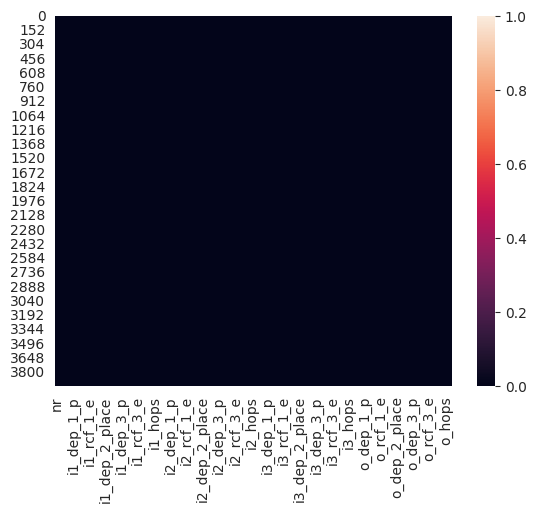

In [188]:
sns.heatmap(df3.isna())

<Axes: >

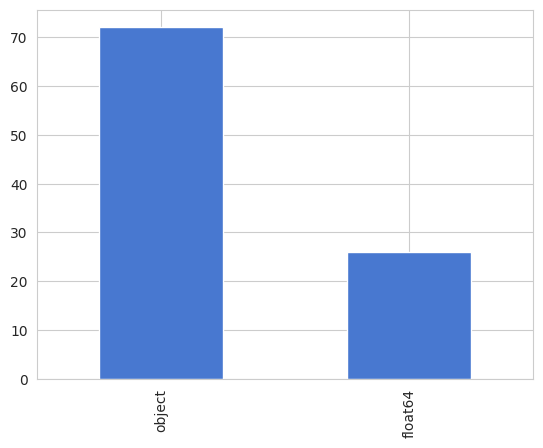

In [189]:
df3.dtypes.value_counts().plot(kind='bar')

In [190]:

df3.replace('?', np.nan, inplace=True)


<Axes: >

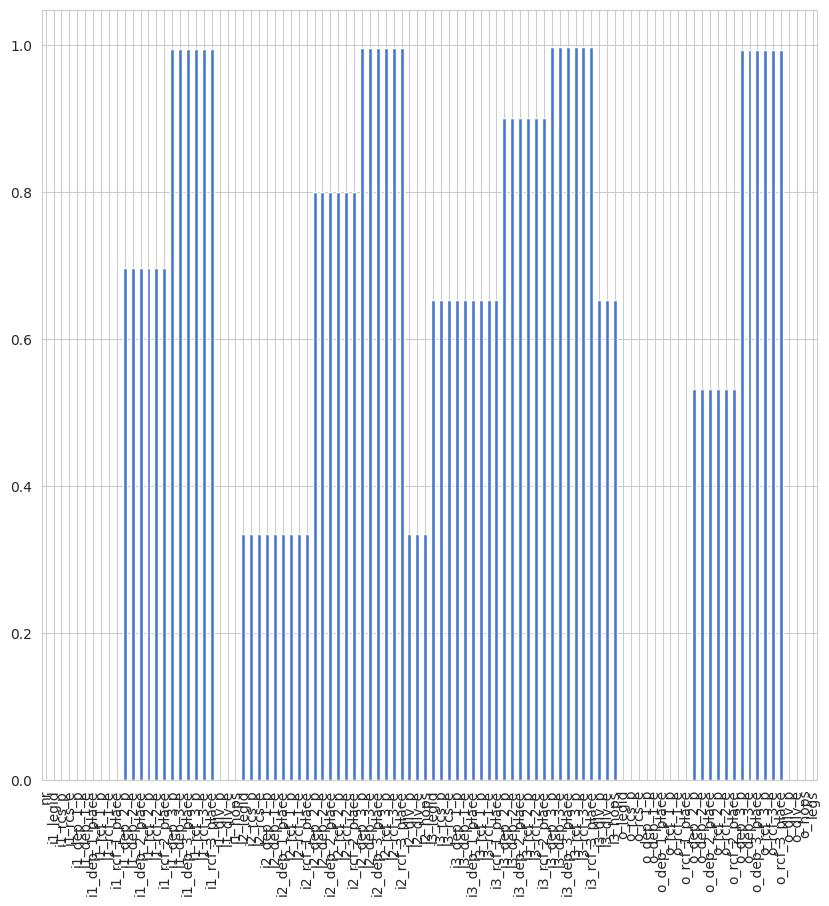

In [191]:
plt.figure(figsize=(10,10))
(df3.isna().sum()/df3.shape[0]).plot(kind='bar')

In [192]:
dfc = df3.loc[: , df3.isna().sum()/df3.shape[0] < 0.5]

In [193]:
dfc.shape

(3943, 38)

<Axes: >

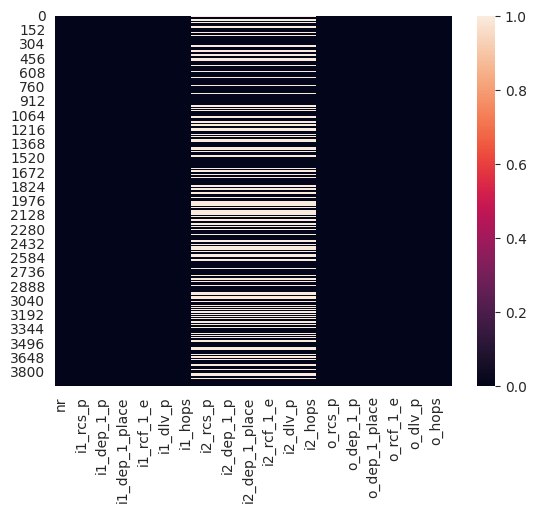

In [194]:
sns.heatmap(dfc.isna())

In [195]:
dfc.isna().sum()/dfc.shape[0]

nr                0.000254
i1_legid          0.000254
i1_rcs_p          0.000254
i1_rcs_e          0.000254
i1_dep_1_p        0.000254
i1_dep_1_e        0.000254
i1_dep_1_place    0.000254
i1_rcf_1_p        0.000254
i1_rcf_1_e        0.000254
i1_rcf_1_place    0.000254
i1_dlv_p          0.000254
i1_dlv_e          0.000254
i1_hops           0.000254
i2_legid          0.334517
i2_rcs_p          0.334517
i2_rcs_e          0.334517
i2_dep_1_p        0.334517
i2_dep_1_e        0.334517
i2_dep_1_place    0.334517
i2_rcf_1_p        0.334517
i2_rcf_1_e        0.334517
i2_rcf_1_place    0.334517
i2_dlv_p          0.334517
i2_dlv_e          0.334517
i2_hops           0.334517
o_legid           0.000254
o_rcs_p           0.000254
o_rcs_e           0.000254
o_dep_1_p         0.000254
o_dep_1_e         0.000254
o_dep_1_place     0.000254
o_rcf_1_p         0.000254
o_rcf_1_e         0.000254
o_rcf_1_place     0.000254
o_dlv_p           0.000254
o_dlv_e           0.000254
o_hops            0.000254
l

In [196]:
dfc.dtypes

nr                float64
i1_legid          float64
i1_rcs_p          float64
i1_rcs_e          float64
i1_dep_1_p        float64
i1_dep_1_e        float64
i1_dep_1_place    float64
i1_rcf_1_p        float64
i1_rcf_1_e        float64
i1_rcf_1_place    float64
i1_dlv_p          float64
i1_dlv_e          float64
i1_hops           float64
i2_legid           object
i2_rcs_p           object
i2_rcs_e           object
i2_dep_1_p         object
i2_dep_1_e         object
i2_dep_1_place     object
i2_rcf_1_p         object
i2_rcf_1_e         object
i2_rcf_1_place     object
i2_dlv_p           object
i2_dlv_e           object
i2_hops            object
o_legid           float64
o_rcs_p           float64
o_rcs_e           float64
o_dep_1_p         float64
o_dep_1_e         float64
o_dep_1_place     float64
o_rcf_1_p         float64
o_rcf_1_e         float64
o_rcf_1_place     float64
o_dlv_p           float64
o_dlv_e           float64
o_hops            float64
legs              float64
dtype: objec

In [197]:
for col in dfc.select_dtypes('object'):
    print(col, " -------------------------", dfc[col].unique())
    dfc[col] = pd.to_numeric(dfc[col], errors='coerce')
    dfc[col] = dfc[col].fillna(dfc[col].mean()).astype(int)



i2_legid  ------------------------- ['573' '13946' nan ... '12490' '3848' '1151']
i2_rcs_p  ------------------------- ['3315' '2964' nan ... '1542' '1111' '2562']
i2_rcs_e  ------------------------- ['2880' '2888' nan ... '1038' '650' '2400']
i2_dep_1_p  ------------------------- ['300' '180' nan '525' '240' '150' '420' '90' '170' '330' '155' '360'
 '165' '600' '120' '135' '250' '385' '110' '960' '210' '780' '270' '1470'
 '540' '1500' '1190' '245' '205' '1020' '570' '410' '1015' '620' '1140'
 '230' '426' '650' '220' '480' '310' '140' '506' '195' '541' '1260' '710'
 '225' '660' '355' '745' '615' '605' '900' '715' '510' '980' '260' '1445'
 '160' '215' '1035' '285' '595' '130' '400' '430' '185' '730' '905' '390'
 '785' '435' '630' '340' '485']
i2_dep_1_e  ------------------------- ['696' '239' nan ... '94' '1359' '1016']
i2_dep_1_place  ------------------------- ['431' '257' nan '128' '815' '308' '281' '413' '671' '349' '485' '134'
 '579' '614' '628' '700' '476' '411' '441' '256' '456' '1

/tmp/ipykernel_195596/287529813.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc[col] = pd.to_numeric(dfc[col], errors='coerce')
/tmp/ipykernel_195596/287529813.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc[col] = dfc[col].fillna(dfc[col].mean()).astype(int)
/tmp/ipykernel_195596/287529813.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

<Axes: >

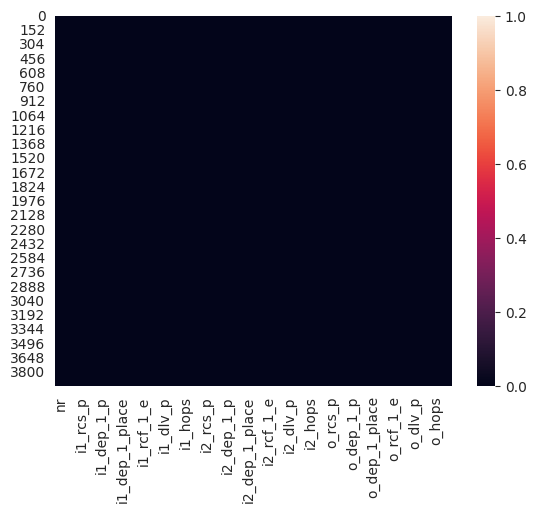

In [198]:
sns.heatmap(dfc.isna())

<Axes: >

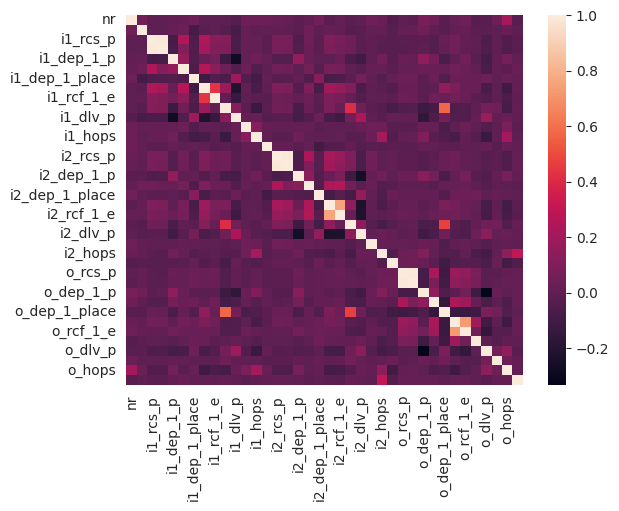

In [199]:
sns.heatmap(dfc.corr(), annot=False)

# 4 - Dataset 4

In [200]:
df4.head()

,Date,BUDAPEST,BARANYA,BACS,BEKES,BORSOD,CSONGRAD,FEJER,GYOR,HAJDU,...,JASZ,KOMAROM,NOGRAD,PEST,SOMOGY,SZABOLCS,TOLNA,VAS,VESZPREM,ZALA
0,03/01/2005,168,79,30,173,169,42,136,120,162,...,130,57,2,178,66,64,11,29,87,68
1,10/01/2005,157,60,30,92,200,53,51,70,84,...,80,50,29,141,48,29,58,53,68,26
2,17/01/2005,96,44,31,86,93,30,93,84,191,...,64,46,4,157,33,33,24,18,62,44
3,24/01/2005,163,49,43,126,46,39,52,114,107,...,63,54,14,107,66,50,25,21,43,31
4,31/01/2005,122,78,53,87,103,34,95,131,172,...,61,49,11,124,63,56,7,47,85,60


In [201]:
df4.isna().sum()

Date        0
BUDAPEST    0
BARANYA     0
BACS        0
BEKES       0
BORSOD      0
CSONGRAD    0
FEJER       0
GYOR        0
HAJDU       0
HEVES       0
JASZ        0
KOMAROM     0
NOGRAD      0
PEST        0
SOMOGY      0
SZABOLCS    0
TOLNA       0
VAS         0
VESZPREM    0
ZALA        0
dtype: int64

In [202]:
df4 = df4.drop('Date' , axis =1)

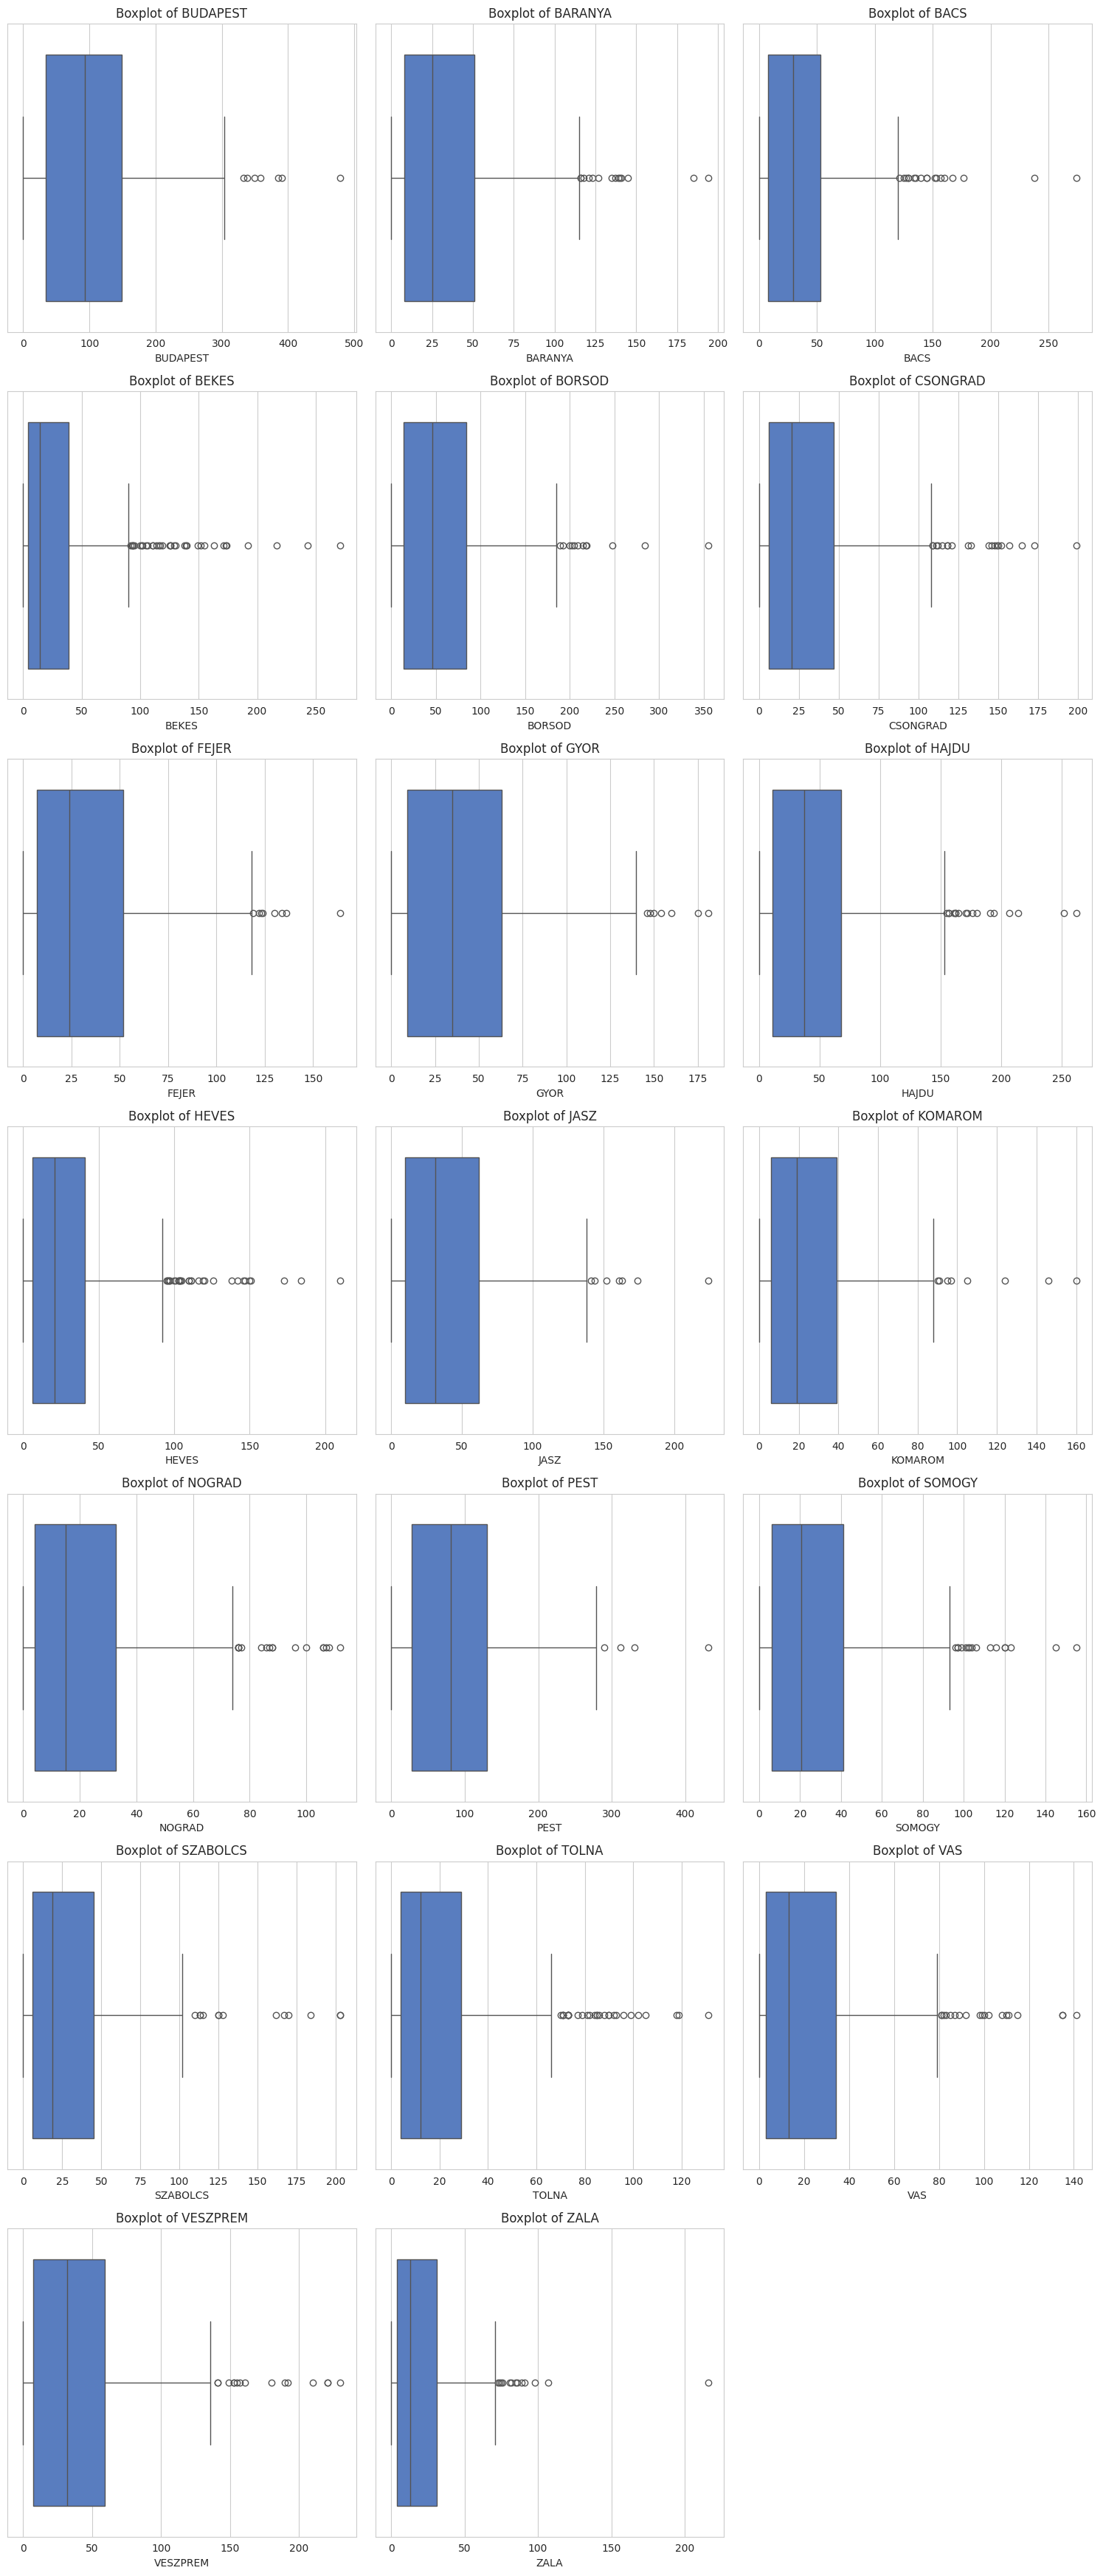

In [203]:
plot_box_plot(df4)

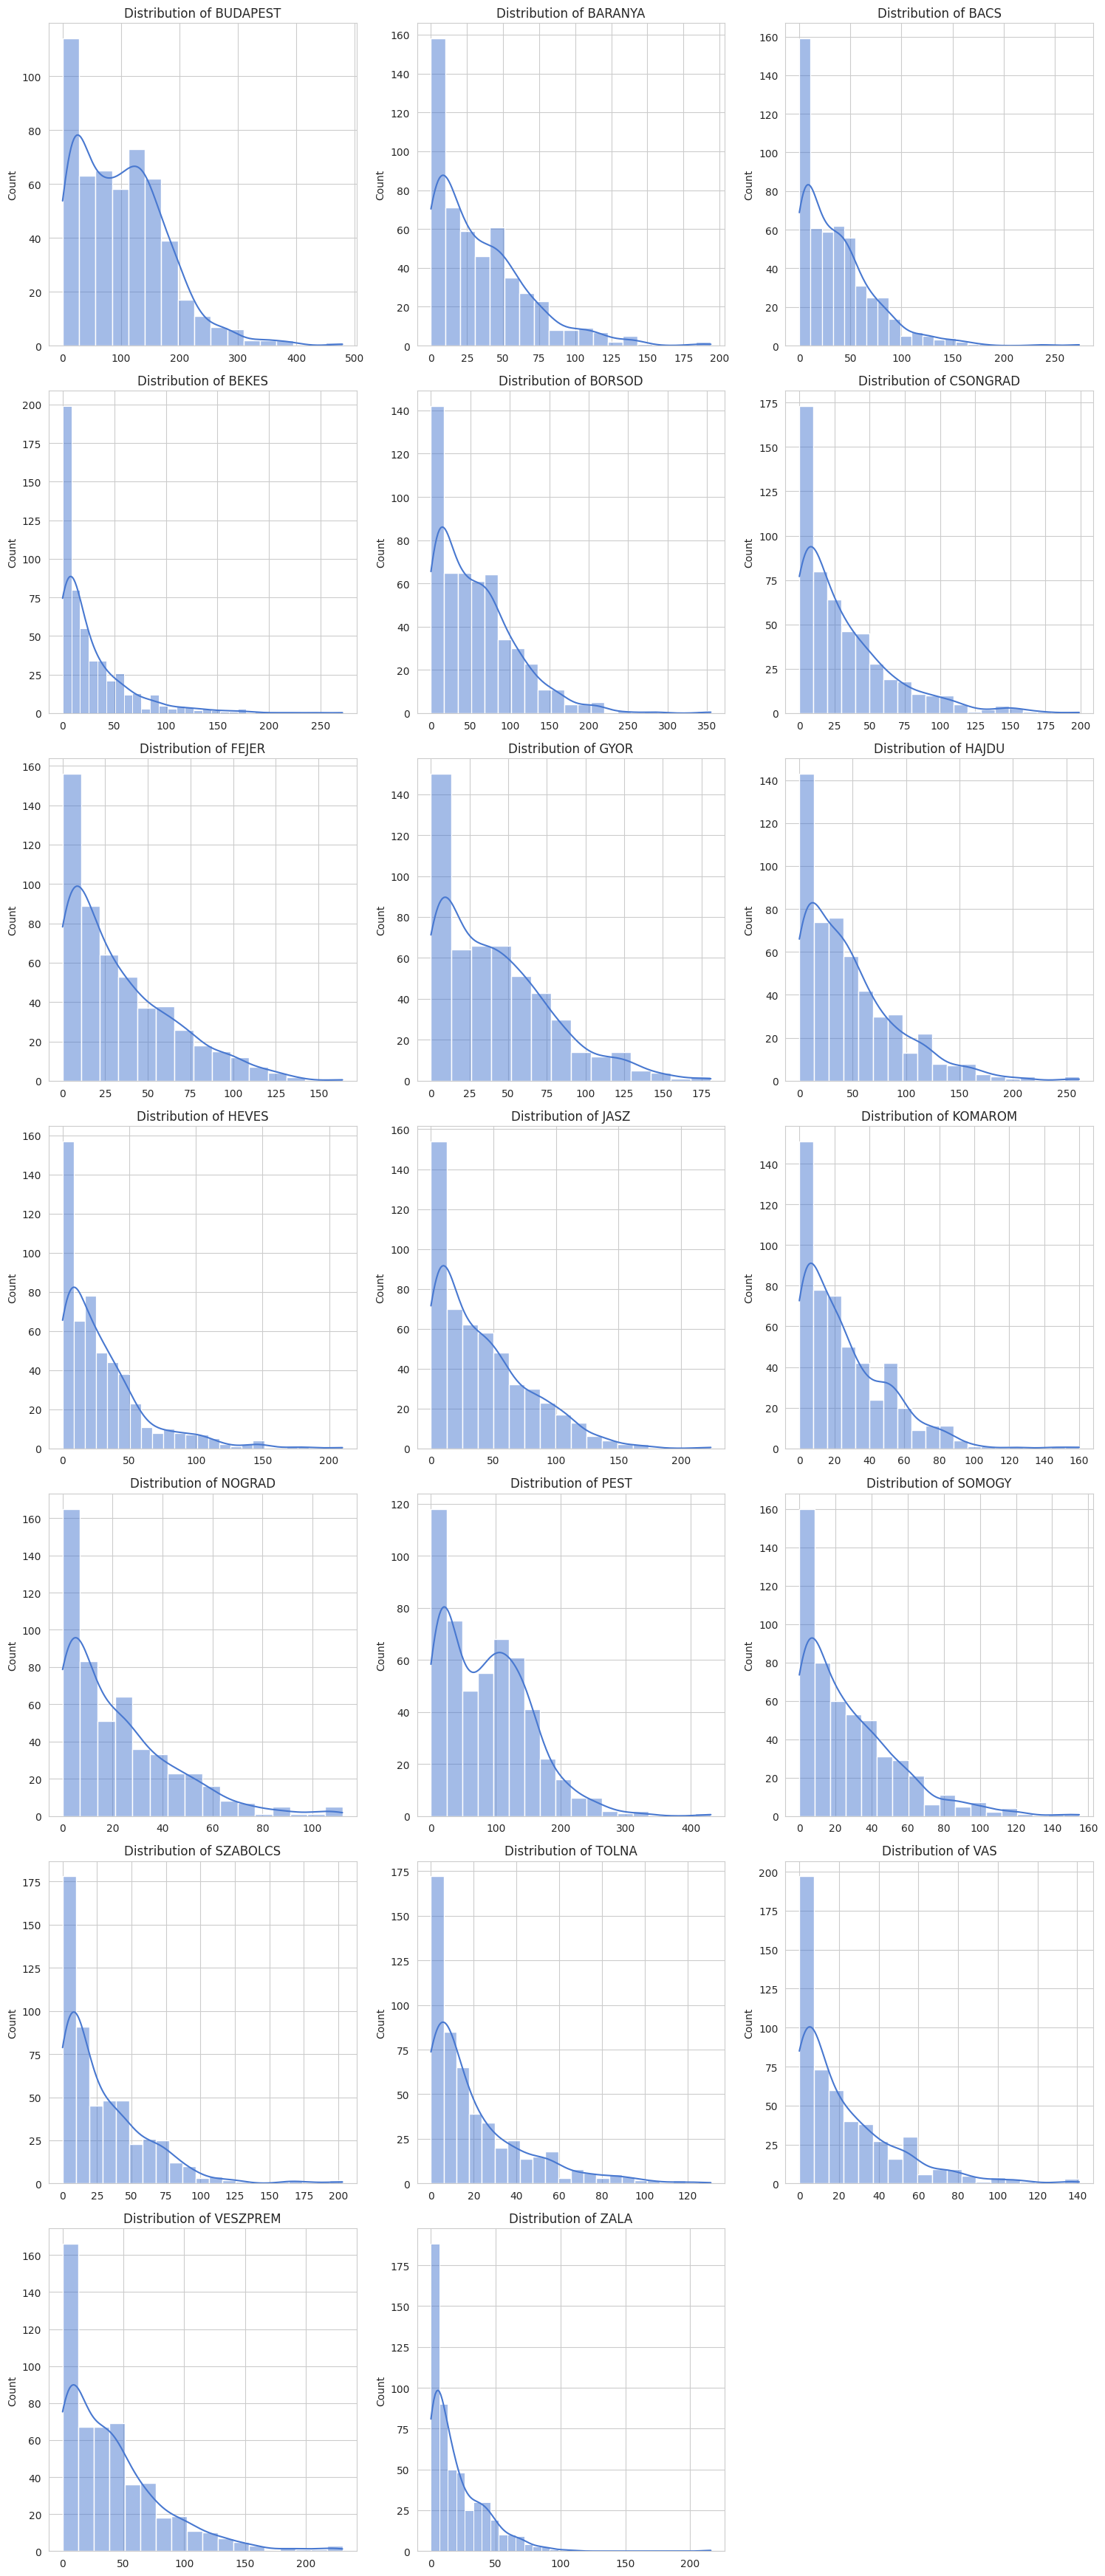

In [204]:
plot_all_distributions(df4)

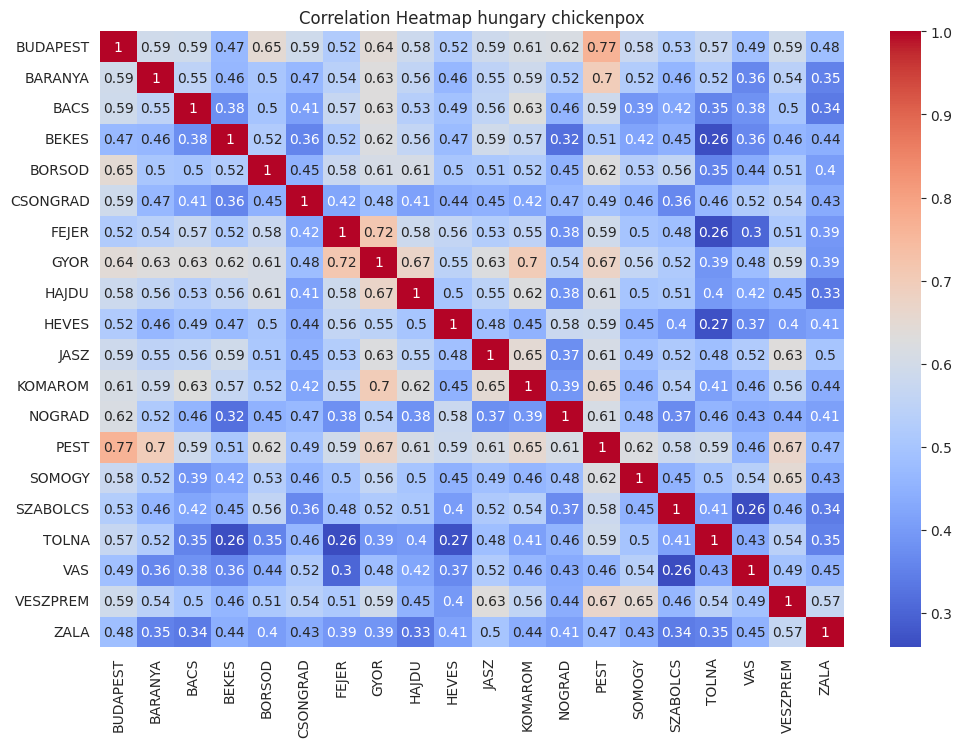

In [205]:
plot_correlation_heatmap(df4, title="Correlation Heatmap hungary chickenpox",figsize=(12, 8))

In [206]:

def plot_pca_variance(dataframes):
    """
    This function takes a list of DataFrames, performs standardization,
    applies PCA to each DataFrame, and plots the cumulative explained variance
    for each principal component on the same plot.
    An additional bar chart is added to the right to show the explained variance
    by each principal component.
    
    Parameters:
    - dataframes: list of pandas DataFrames
    """
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for i, df in enumerate(dataframes):
        df = df.dropna()
        
        df_numeric = df.select_dtypes(include=[np.number], exclude=["datetime64", "object"])
        
        if df_numeric.shape[1] == 0:
            print(f"DataFrame {i+1} contains no numeric columns, skipping.")
            continue
        
        scaler = StandardScaler()
        df_scaled = scaler.fit_transform(df_numeric)
        
        pca = PCA()
        pca.fit(df_scaled)
        
        explained_variance = pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance)
        
        # Cumulative explained variance plot
        axes[0].plot(cumulative_variance, label=f'DataFrame {i+1}')
        
        bars = axes[1].bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, label=f'DataFrame {i+1}')
        axes[1].bar_label(bars, fmt='%.2f')
    
    axes[0].set_xlabel('Number of Principal Components')
    axes[0].set_ylabel('Cumulative Explained Variance')
    axes[0].set_title('Cumulative Explained Variance by PCA')
    axes[0].legend()
    axes[0].grid()
    
    axes[1].set_xlabel('Principal Components')
    axes[1].set_ylabel('Percentage of Explained Variance')
    axes[1].set_title('Explained Variance by Each Principal Component')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig("pca.png")
    plt.show()


In [207]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def plot_pca_variance(dataframes, dataset_names):
    """
    This function takes a list of DataFrames, performs standardization,
    applies PCA to each DataFrame, and plots the cumulative explained variance
    for each principal component on the same plot. An additional bar chart 
    on the right shows the explained variance by each principal component.

    Parameters:
    - dataframes: list of pandas DataFrames
    - dataset_names: list of names corresponding to the DataFrames
    """
    
    sns.set_style("whitegrid")
    sns.set_palette("muted")
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Define colors for better readability
    colors = sns.color_palette("tab10", len(dataframes))

    for i, (df, name) in enumerate(zip(dataframes, dataset_names)):
        df = df.dropna()
        
        df_numeric = df.select_dtypes(include=[np.number])

        if df_numeric.shape[1] == 0:
            print(f"DataFrame '{name}' contains no numeric columns, skipping.")
            continue

        # Standardize the data
        scaler = StandardScaler()
        df_scaled = scaler.fit_transform(df_numeric)

        # Apply PCA
        pca = PCA()
        pca.fit(df_scaled)

        explained_variance = pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance)

        # Cumulative explained variance plot
        axes[0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
                     label=name, color=colors[i], lw=2, marker="o")

        # Bar plot for explained variance per component
        bars = axes[1].bar(range(1, len(explained_variance) + 1), explained_variance, 
                           alpha=0.8, label=name, color=colors[i])

        # Annotate bars with percentage values
        for bar in bars:
            height = bar.get_height()
            if height > 0.02:  # Avoid clutter for very small values
                axes[1].text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", 
                             ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Styling for the cumulative variance plot
    axes[0].set_xlabel('Number of Principal Components', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Cumulative Explained Variance', fontsize=14, fontweight='bold')
    axes[0].set_title('Cumulative Explained Variance by PCA', fontsize=16, fontweight='bold')
    axes[0].legend(fontsize=12)
    axes[0].grid(True, linestyle="--", alpha=0.6)

    # Styling for the explained variance bar plot
    axes[1].set_xlabel('Principal Components', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Percentage of Explained Variance', fontsize=14, fontweight='bold')
    axes[1].set_title('Explained Variance by Each Principal Component', fontsize=16, fontweight='bold')
    axes[1].legend(fontsize=12)
    axes[1].set_xticks(range(1, min(10, len(explained_variance)) + 1))
    axes[1].set_xlim(0.5, min(10, len(explained_variance)) + 0.5)
    
    plt.tight_layout()
    plt.savefig("pca_analysis.pdf", format="pdf", dpi=300)  # High-quality export
    plt.show()


In [208]:


def plot_pca_cumulative_variance2(dataframes, dataset_names):
    """
    This function applies standardization and PCA to multiple DataFrames,
    then plots the cumulative explained variance curve.

    Parameters:
    - dataframes: List of pandas DataFrames
    - dataset_names: List of corresponding dataset names
    """
    
    # Set Seaborn style for a better visual appearance
    sns.set_style("whitegrid")
    sns.set_palette("muted")

    plt.figure(figsize=(10, 6))

    # Assign distinct colors for each dataset
    colors = sns.color_palette("tab10", len(dataframes))

    for i, (df, name) in enumerate(zip(dataframes, dataset_names)):
        df = df.dropna()
        df_numeric = df.select_dtypes(include=[np.number])

        if df_numeric.shape[1] == 0:
            print(f" DataFrame '{name}' contains no numerical columns, skipping.")
            continue

        scaler = StandardScaler()
        df_scaled = scaler.fit_transform(df_numeric)

        # Apply PCA
        pca = PCA()
        pca.fit(df_scaled)

        # Compute cumulative explained variance
        cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

        # Plot the curve
        plt.plot(
            range(1, len(cumulative_variance) + 1),
            cumulative_variance,
            marker="o",
            label=name,
            color=colors[i],
            lw=2
        )

    # Customize the plot
    

    plt.xlabel("# of principal components", fontsize=14, fontweight="bold")
    plt.ylabel("Cumulative explained variance", fontsize=14, fontweight="bold")
    plt.title("Cumulative variance explained by PCA", fontsize=16, fontweight="bold")
    
    plt.axhline(y=0.85, color="r", linestyle="--", label="Threshold of 85%") 
    plt.legend(fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    
    plt.tight_layout()
    plt.savefig("../images_conf/pca_cumulative_en_variance.eps")  
    plt.show()


In [209]:
df = [

    {
        'df': df1,
        'name':'Air Quality' 
    },
    {
        'df': df2,
        'name':'HCV' 
    },
     {
        'df': dfc,
        'name':'Cargo 2000' 
    },
     {
        'df': df4,
        'name':'Chickenpox' 
    },
]


In [210]:
df2.shape

(615, 11)

In [211]:


def plot_pca_barplot(dataframes, dataset_names):
    """
    Cette fonction prend une liste de DataFrames, applique une standardisation,
    réalise une PCA et affiche un barplot clair et bien annoté de la variance expliquée 
    par chaque composant principal.
    
    Paramètres :
    - dataframes: Liste de pandas DataFrames
    - dataset_names: Liste de noms des DataFrames
    """
    
    colors = sns.color_palette("tab10", len(dataframes)) 

    # Préparer les données pour Seaborn
    data = []

    for i, (df, name) in enumerate(zip(dataframes, dataset_names)):
        df = df.dropna()
        df_numeric = df.select_dtypes(include=[np.number])

        if df_numeric.shape[1] == 0:
            print(f" DataFrame '{name}' ne contient pas de colonnes numériques, ignoré.")
            continue

        scaler = StandardScaler()
        df_scaled = scaler.fit_transform(df_numeric)

        pca = PCA()
        pca.fit(df_scaled)
        explained_variance = pca.explained_variance_ratio_

        # Ajouter chaque composant et son dataset associé dans la liste
        for j, var in enumerate(explained_variance):
            if j < 10:  # Ne pas afficher trop de composantes pour éviter la surcharge visuelle
                data.append([j + 1, var, name])

    df_plot = pd.DataFrame(data, columns=["Composante", "Variance expliquée", "Dataset"])

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        x="Composante", 
        y="Variance expliquée", 
        hue="Dataset", 
        data=df_plot,
        palette=colors
    )

    # Ajouter les annotations pour chaque barre
    for p in ax.patches:
        if p.get_height() > 0.01:  # Éviter les annotations inutiles sur valeurs très faibles
            ax.annotate(f"{p.get_height():.2f}", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha="center", va="bottom", fontsize=10, fontweight="bold")

    # Amélioration du design
    plt.xlabel("Composantes Principales", fontsize=14, fontweight="bold")
    plt.ylabel("Variance expliquée (%)", fontsize=14, fontweight="bold")
    plt.title("Variance expliquée par les Composantes Principales", fontsize=16, fontweight="bold")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title="Dataset", fontsize=12, title_fontsize=12)
    plt.ylim(0, max(df_plot["Variance expliquée"]) + 0.05)  # Ajuster l'échelle pour lisibilité

    plt.tight_layout()
    plt.savefig("pca_barplot.pdf", format="pdf", dpi=300)  # Export en haute qualité
    plt.show()


In [212]:
dataframes = [d["df"] for d in df]  
dataset_names = [d["name"] for d in df]  # Extraction des noms
#plot_pca_cumulative_variance2(dataframes, dataset_names)
#plot_pca_barplot(dataframes, dataset_names)


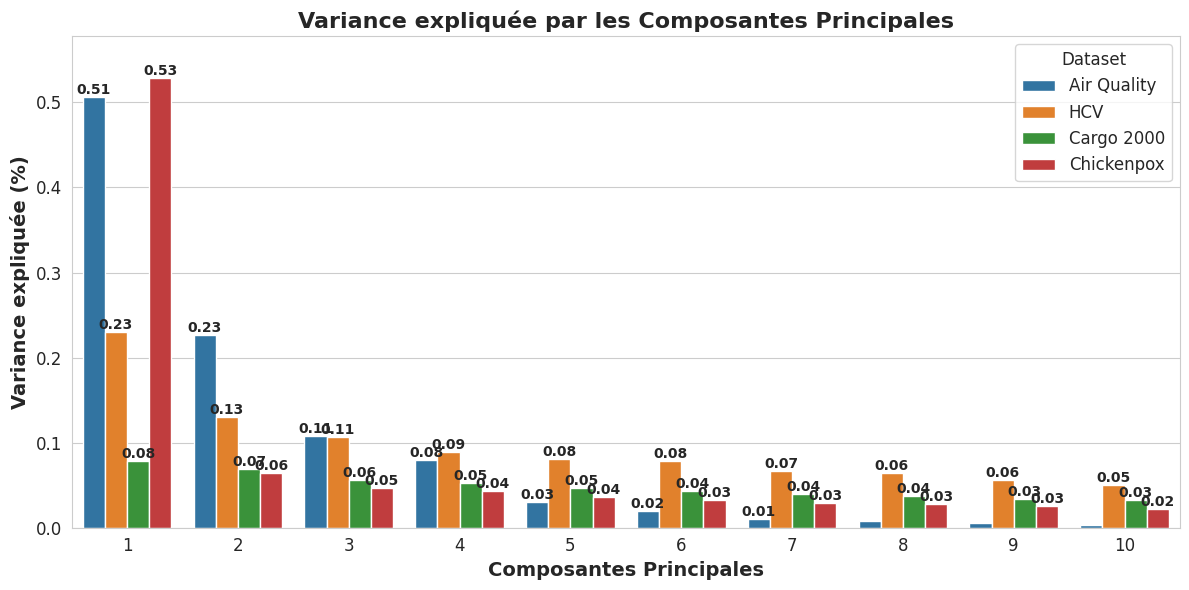

In [213]:
dataframes = [d["df"] for d in df]  
dataset_names = [d["name"] for d in df]  
plot_pca_barplot(dataframes, dataset_names)


In [214]:
df_air1 = df1.drop(["Date", "Time"], axis = 1)

In [215]:
def apply_pca_and_get_features(df):
    df = df.dropna()
    df_numeric = df.select_dtypes(include=[np.number], exclude=["datetime64", "object"])
    
    df = df_numeric.copy()
    X_scaled = StandardScaler().fit_transform(df.select_dtypes(include=[np.number]))
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    print(pca.explained_variance_ratio_)
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)


    # Calcul des charges pour chaque composante principale
    loadings = pd.DataFrame(pca.components_.T, index=df.columns, columns=[f'Composante {i+1}' for i in range(len(pca.components_))])
    # Choisir les composantes principales qui expliquent 85% de la variance cumulée
    n_components = np.argmax(cumulative_variance >= 0.85) + 1
    print(f"Nombre de composantes pour expliquer 85% de la variance: {n_components}")


    selected_features = {}
    threshold = 0.85  

    for i in range(n_components):  
        sorted_loadings = loadings.iloc[:, i].abs().sort_values(ascending=False)
    
        # Calculer la somme cumulée des charges
        cumulative_influence = sorted_loadings.cumsum() / sorted_loadings.sum()
    
        num_vars = (cumulative_influence >= threshold).values.argmax() + 1  # Assure que num_vars est un entier
    
        # Sélectionner les variables jusqu'à ce nombre
        selected_features[f'Composante {i+1}'] = sorted_loadings.index[:num_vars].tolist()

    features = set()

    for vars_ in selected_features.values():
        features.update(vars_)  # Ajoute directement tous les éléments de vars_

    features = list(features)

    #for comp, vars_ in selected_features.items():
    #    print(f"{comp}: {vars_}")

    #print("Toutes les variables uniques sélectionnées :", features, "nombre", len(features))

    return loadings.iloc[:,:n_components], n_components, features


In [216]:

def plot_multiple_charge(df, feature_importance, num_rows, num_cols):
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 10))
    columns = list(feature_importance.columns)
    
    for i in range(num_rows):
        for j in range(num_cols):
            col_index = i * num_cols + j
            # Vérifiez si col_index dépasse le nombre de colonnes
            if col_index < len(columns) and columns[col_index] in feature_importance.columns:
                # Tracé du graphique pour la composante actuelle
                axes[i, j].barh(feature_importance.index, feature_importance[columns[col_index]])
                axes[i, j].set_title(f"Charge de {columns[col_index]}")
                axes[i, j].grid(axis='x')
                axes[i, j].axvline(0, color='black', linewidth=0.8)  # Ligne de référence à 0
                axes[i, j].set_xlabel('Charge')
                axes[i, j].set_ylabel('Variables')
            else:
                pass
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()


In [217]:
importance_features_Air, n_components_Air, features_Air= apply_pca_and_get_features(df1)

[5.06510555e-01 2.26533098e-01 1.08374244e-01 7.94065071e-02
 3.02875950e-02 1.92912061e-02 1.01207970e-02 8.12917837e-03
 5.88479857e-03 3.06243457e-03 2.17110797e-03 2.00554469e-04
 2.79241312e-05]
Nombre de composantes pour expliquer 85% de la variance: 4


In [218]:
len(set(features_Air))

13

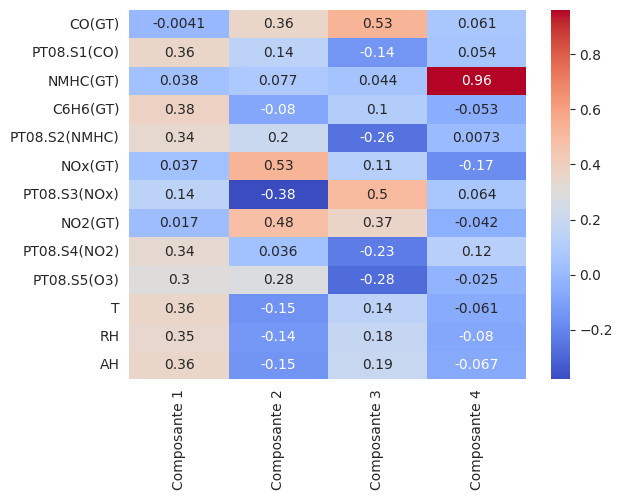

In [219]:
sns.heatmap(importance_features_Air, cmap='coolwarm', annot=True)
plt.show()

In [220]:
importance_features_Air

,Composante 1,Composante 2,Composante 3,Composante 4
CO(GT),-0.004097,0.361850,0.528451,0.060813
PT08.S1(CO),0.363756,0.141825,-0.142432,0.054137
NMHC(GT),0.038283,0.076568,0.044226,0.961505
C6H6(GT),0.380574,-0.079843,0.104671,-0.053108
PT08.S2(NMHC),0.337779,0.196242,-0.260630,0.007255
NOx(GT),0.037338,0.527840,0.112954,-0.173688
PT08.S3(NOx),0.143043,-0.380512,0.501683,0.064107
NO2(GT),0.016895,0.482822,0.365958,-0.042490
PT08.S4(NO2),0.337445,0.035885,-0.232281,0.121405
PT08.S5(O3),0.298613,0.275625,-0.282809,-0.025152


In [221]:
for col in importance_features_Air.columns:
    # Filtrer les valeurs qui sont supérieures ou égales à 0.5 en valeur absolue
    mask = importance_features_Air[col].abs() >= 0.5
    if mask.any():
        # Récupérer les index et les valeurs correspondants
        indices = importance_features_Air.index[mask]
        valeurs = importance_features_Air[col][mask]
        for idx, val in zip(indices, valeurs):
            print(f"{col} - Index: {idx}, Valeur: {val}")


Composante 2 - Index: NOx(GT), Valeur: 0.5278397825974972
Composante 3 - Index: CO(GT), Valeur: 0.5284512132527728
Composante 3 - Index: PT08.S3(NOx), Valeur: 0.5016825786135845
Composante 4 - Index: NMHC(GT), Valeur: 0.9615049088592366


In [222]:

def extract_significant_variables(df, threshold=0.5):
    """
    Extrait les noms et les valeurs des variables dont le loading est supérieur ou égal au seuil dans chaque colonne d'un DataFrame.
    Args:
        df (pd.DataFrame): DataFrame contenant les loadings.
        threshold (float): Seuil à partir duquel une variable est considérée comme significative (en valeur absolue).
    Returns:
        pd.DataFrame: Un DataFrame récapitulatif avec le nom des variables et le nombre de variables sélectionnées par colonne.
    """
    selected_variables = []
    
    for col in df.columns:
        # Filtrer les valeurs qui sont supérieures ou égales au seuil en valeur absolue
        mask = df[col].abs() >= threshold
        if mask.any():
            # Récupérer les noms des variables répondant au critère dans cette colonne
            variables = df.index[mask].tolist()
            for va in variables:
                selected_variables.append(va)

    return selected_variables

def process_multiple_dfs(dfs, threshold=0.5):
    """
    Applique la fonction de sélection sur plusieurs DataFrames et combine les résultats.
    Args:
        dfs (list of pd.DataFrame): Liste de DataFrames contenant les loadings à analyser.
        threshold (float): Seuil pour la sélection des variables.
    Returns:
        pd.DataFrame: DataFrame combiné avec les noms des variables sélectionnées et leur nombre par DataFrame et colonne.
    """
    all_results = []
    
    for i, df in enumerate(dfs):
        # Appliquer la fonction d'extraction sur chaque DataFrame de la liste
        summary_df = extract_significant_variables(df, threshold)
        all_results.append(summary_df)
    
    return all_results


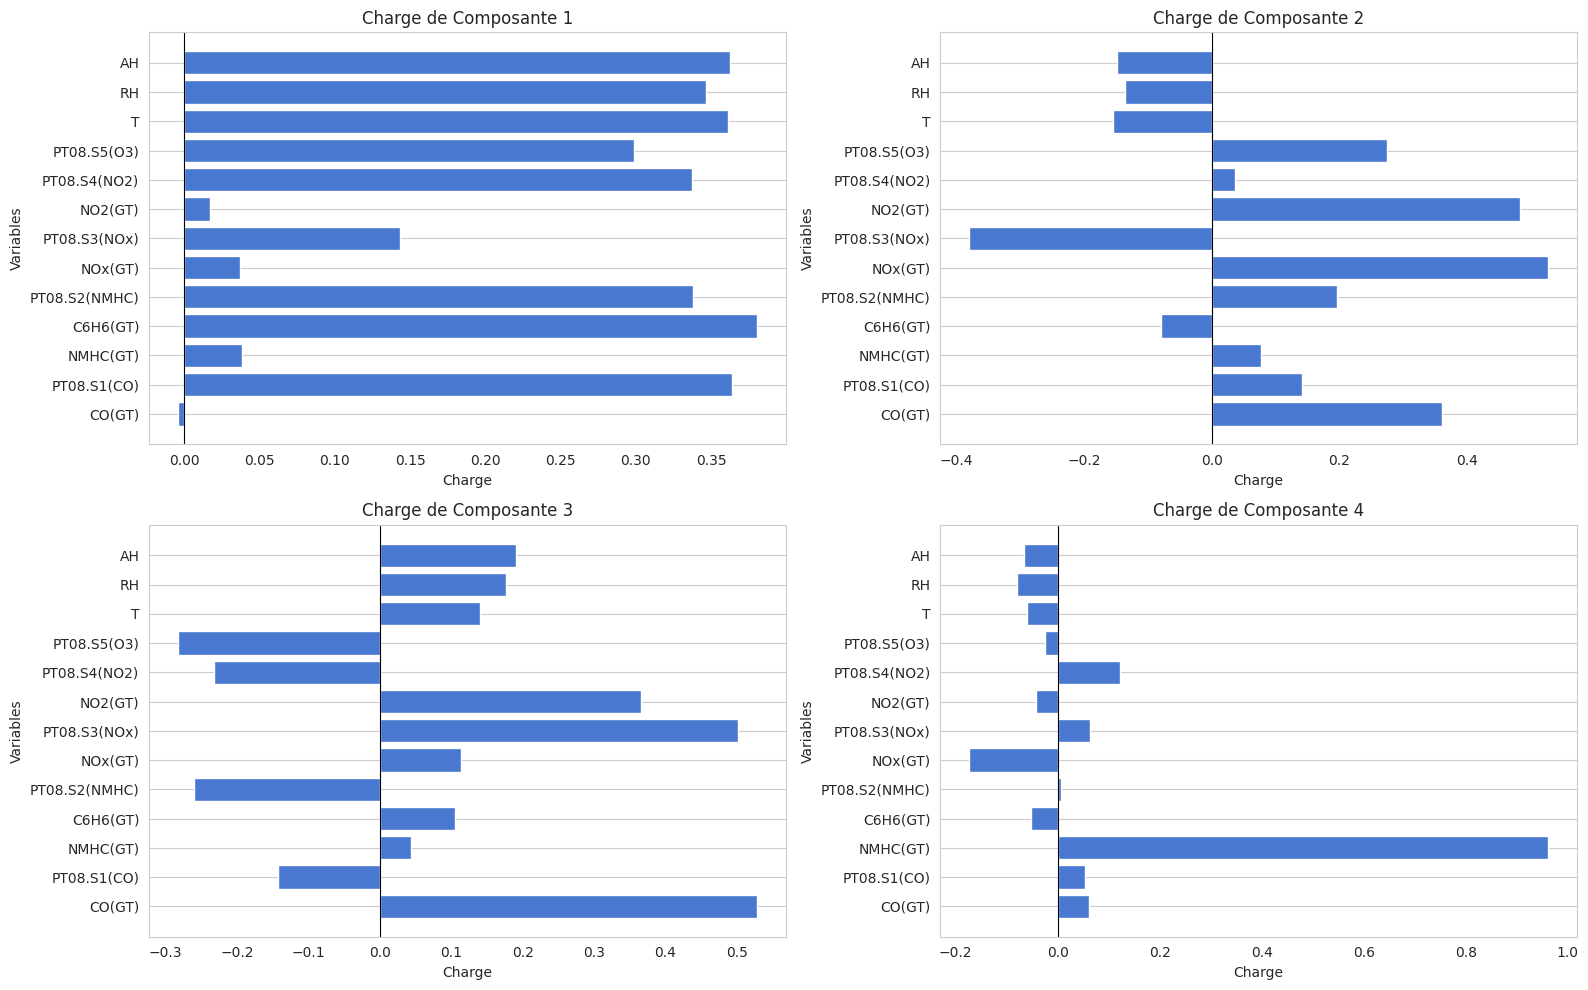

In [223]:
plot_multiple_charge(df1.drop(["Date", "Time"], axis=1), importance_features_Air, 2,2)

In [224]:
print(df2.shape)
importance_features_hcv, n_components_hcv, features_hcv= apply_pca_and_get_features(df2)


(615, 11)
[0.23062592 0.13064047 0.107102   0.08909607 0.08120953 0.07866844
 0.06699972 0.06425998 0.05605882 0.04975615 0.0455829 ]
Nombre de composantes pour expliquer 85% de la variance: 9


In [225]:
len(set(features_hcv))

11

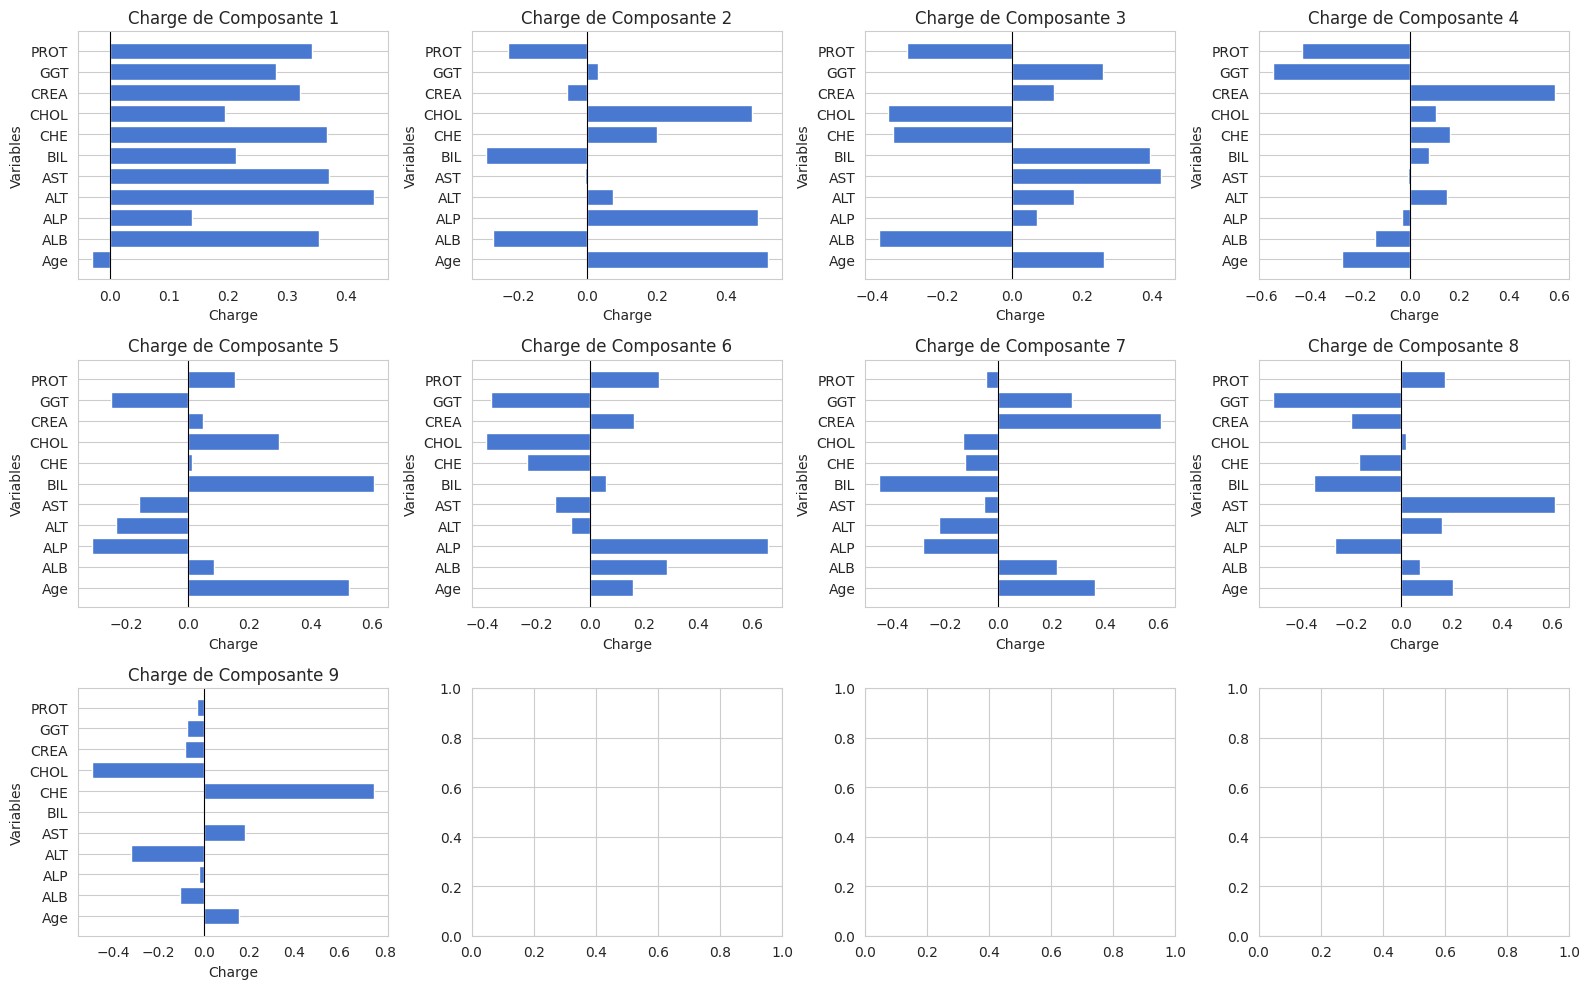

In [226]:
plot_multiple_charge(df2, importance_features_hcv, 3,4)

In [227]:
print(dfc.shape)
importance_features_dfc, n_components_dfc, features_dfc= apply_pca_and_get_features(dfc)


(3943, 38)
[7.83557114e-02 6.95964088e-02 5.63928467e-02 5.29933720e-02
 4.62999636e-02 4.35652801e-02 4.01166140e-02 3.69124373e-02
 3.41535833e-02 3.20807461e-02 3.15294864e-02 3.02760876e-02
 2.81466172e-02 2.72511823e-02 2.68926216e-02 2.65460573e-02
 2.60061528e-02 2.53768723e-02 2.45463317e-02 2.38248452e-02
 2.33380601e-02 2.26450964e-02 2.20846826e-02 2.11028500e-02
 2.10342984e-02 1.74070439e-02 1.72458182e-02 1.67278344e-02
 1.53784363e-02 1.47880605e-02 1.32043150e-02 1.17427149e-02
 1.00709595e-02 6.34999029e-03 5.90440265e-03 5.59501343e-05
 3.90281443e-05 1.72410271e-05]
Nombre de composantes pour expliquer 85% de la variance: 24


In [228]:
len(features_dfc)

38

In [229]:
#plot_multiple_charge(dfc, importance_features_dfc, 6,7)

In [230]:
print(df4.shape)
importance_features_df4, n_components_df4, features_df4= apply_pca_and_get_features(df4)


(522, 20)
[0.52821904 0.06386253 0.04639956 0.04353285 0.035635   0.03284406
 0.0295125  0.02840454 0.02608491 0.02236141 0.02032663 0.01896413
 0.0174776  0.01659025 0.01497848 0.01369865 0.01323488 0.0113059
 0.00892692 0.00764016]
Nombre de composantes pour expliquer 85% de la variance: 10


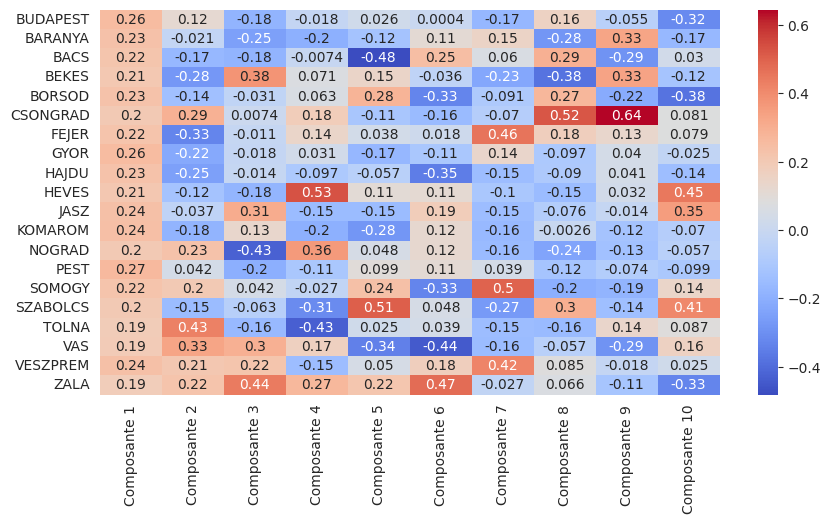

In [231]:
plt.figure(figsize=(10, 5))
sns.heatmap(importance_features_df4, cmap='coolwarm', annot=True)
plt.show()

In [232]:


def plot_loadings_histogram(df, feature_name, seuils=[0.3, 0.4, 0.5], percentiles=[75, 80, 85, 90, 95], 
                           figsize=(12, 6), bins=30):
    """
    Trace l'histogramme des valeurs absolues des loadings d'un DataFrame.

    """
    
    all_values = df.values.flatten()
    abs_values = np.abs(all_values)
    
    plt.figure(figsize=figsize)
    
    plt.subplot(1, 2, 1)
    plt.hist(abs_values, bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
    
    plt.xlabel('Absolute value of the loadings')
    plt.ylabel('Frequency')
    plt.title(f"Distribution of absolute values of loadings: {feature_name}")
    plt.grid(True, alpha=0.3)
    
    colors = ['orange', 'red', 'darkred', 'purple', 'brown']
    for i, seuil in enumerate(seuils):
        color = colors[i % len(colors)]
        plt.axvline(x=seuil, color=color, linestyle='--', label=f'Seuil {seuil}')
    plt.legend()
    
    # Histogramme cumulatif
    plt.subplot(1, 2, 2)
    plt.hist(abs_values, bins=bins, alpha=0.7, color='lightcoral', 
             cumulative=True, density=True, edgecolor='black')
    
    plt.xlabel('Absolute value of the loadings')
    plt.ylabel('Cumulative proportion')
    plt.title(f"Cumulative distribution of loadings: {feature_name}")
    plt.grid(True, alpha=0.3)
    
    # Ajouter les percentiles
    percentile_values = {}
    for p in percentiles:
        val = np.percentile(abs_values, p)
        percentile_values[p] = val
        plt.axvline(x=val, linestyle=':', alpha=0.6, 
                    label=f'{p}th: {val:.3f}')
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"../images_conf/loadings_histogram_{feature_name}EN.eps", format="eps", dpi=300)
    plt.show()
    
    stats = {
        'moyenne': np.mean(abs_values),
        'mediane': np.median(abs_values),
        'ecart_type': np.std(abs_values),
        'min': np.min(abs_values),
        'max': np.max(abs_values),
        'percentiles': percentile_values
    }
    

    total_vars = len(abs_values)
    
    for seuil in seuils:
        count = np.sum(abs_values >= seuil)
        percentage = (count / total_vars) * 100
        print(f"Seuil >= {seuil}: {count:4d} variables ({percentage:5.1f}%)")
    
    # Ajouter quelques seuils supplémentaires pour analyse
    seuils_extra = [0.2, 0.6, 0.7]
    for seuil in seuils_extra:
        if seuil not in seuils:
            count = np.sum(abs_values >= seuil)
            percentage = (count / total_vars) * 100
            print(f"Seuil >= {seuil}: {count:4d} variables ({percentage:5.1f}%)")
    
    print("=" * 50)
    
    return stats

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


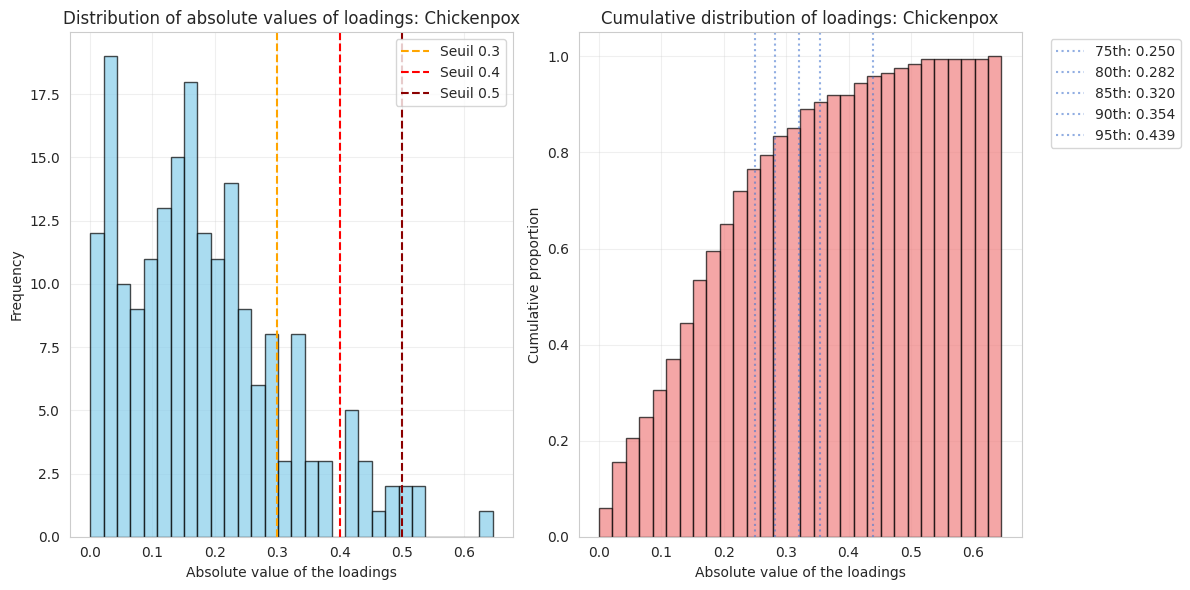

Seuil >= 0.3:   33 variables ( 16.5%)
Seuil >= 0.4:   16 variables (  8.0%)
Seuil >= 0.5:    4 variables (  2.0%)
Seuil >= 0.2:   79 variables ( 39.5%)
Seuil >= 0.6:    1 variables (  0.5%)
Seuil >= 0.7:    0 variables (  0.0%)


{'moyenne': 0.18370589738245374,
 'mediane': 0.16163997181415024,
 'ecart_type': 0.12748389414709366,
 'min': 0.0003989776959876628,
 'max': 0.6449550795389278,
 'percentiles': {75: 0.2498680957326258,
  80: 0.2824284495927445,
  85: 0.32012180592739764,
  90: 0.35445221216491946,
  95: 0.43881222578962337}}

In [233]:
plot_loadings_histogram(importance_features_df4, feature_name="Chickenpox")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


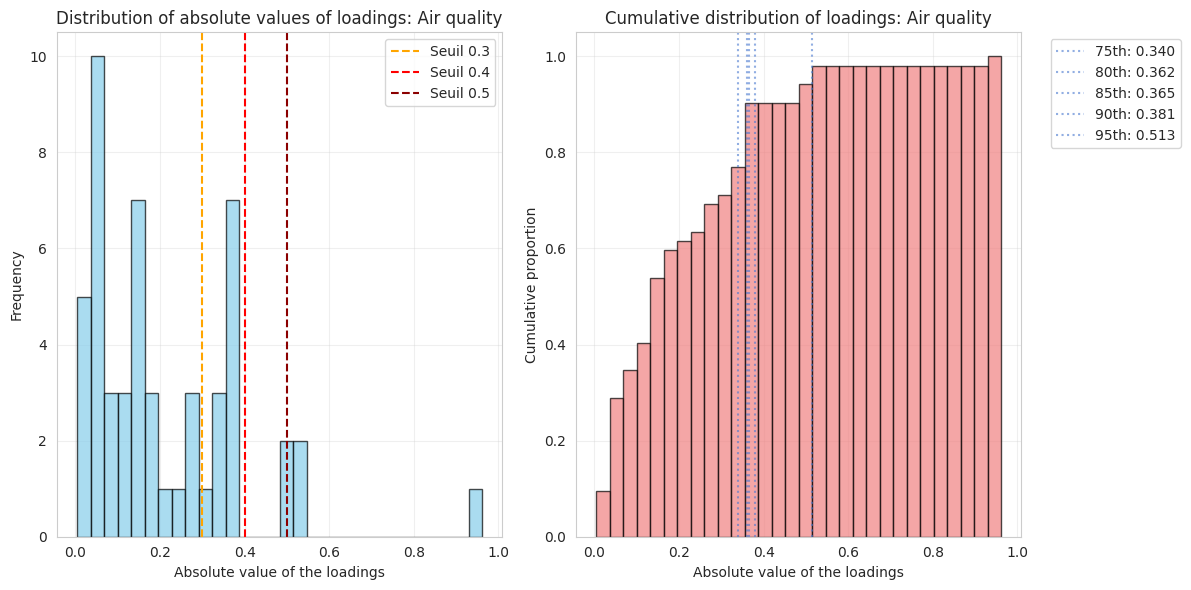

Seuil >= 0.3:   15 variables ( 28.8%)
Seuil >= 0.4:    5 variables (  9.6%)
Seuil >= 0.5:    4 variables (  7.7%)
Seuil >= 0.2:   20 variables ( 38.5%)
Seuil >= 0.6:    1 variables (  1.9%)
Seuil >= 0.7:    1 variables (  1.9%)


{'moyenne': 0.20925972663506892,
 'mediane': 0.14548305809947507,
 'ecart_type': 0.18202594246890505,
 'min': 0.004096611706438271,
 'max': 0.9615049088592366,
 'percentiles': {75: 0.3399788781035985,
  80: 0.36168430064565316,
  85: 0.3645265355543276,
  90: 0.3805681623711479,
  95: 0.5134533204063451}}

In [234]:
plot_loadings_histogram(importance_features_Air, "Air quality") 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


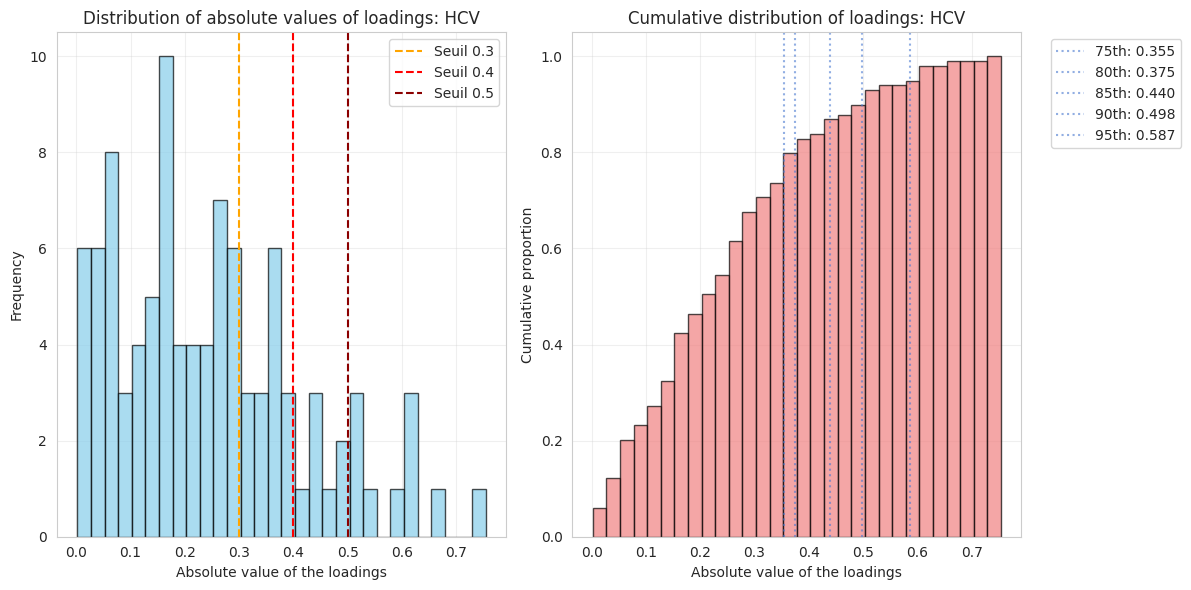

Seuil >= 0.3:   33 variables ( 33.3%)
Seuil >= 0.4:   17 variables ( 17.2%)
Seuil >= 0.5:   10 variables ( 10.1%)
Seuil >= 0.2:   54 variables ( 54.5%)
Seuil >= 0.6:    5 variables (  5.1%)
Seuil >= 0.7:    1 variables (  1.0%)


{'moyenne': 0.24760997518189623,
 'mediane': 0.22203717557415653,
 'ecart_type': 0.17204182950524452,
 'min': 0.0020228164975662254,
 'max': 0.7538320024520774,
 'percentiles': {75: 0.3549577051058238,
  80: 0.3745279956974441,
  85: 0.43956994395220084,
  90: 0.4982968887426154,
  95: 0.5868858792723763}}

In [235]:
plot_loadings_histogram(importance_features_hcv, feature_name="HCV")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


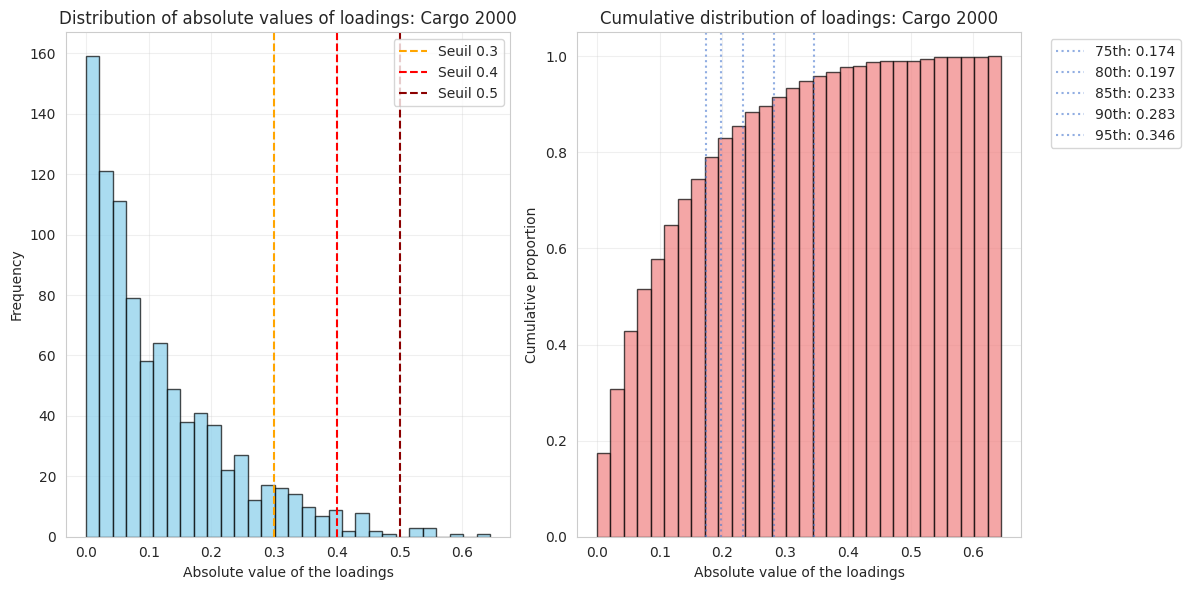

Seuil >= 0.3:   77 variables (  8.4%)
Seuil >= 0.4:   26 variables (  2.9%)
Seuil >= 0.5:    8 variables (  0.9%)
Seuil >= 0.2:  177 variables ( 19.4%)
Seuil >= 0.6:    1 variables (  0.1%)
Seuil >= 0.7:    0 variables (  0.0%)


{'moyenne': 0.11799225906166211,
 'mediane': 0.08093105691764074,
 'ecart_type': 0.11132661979603,
 'min': 4.330310384448825e-05,
 'max': 0.6442381329480724,
 'percentiles': {75: 0.17419905992483703,
  80: 0.19708824947777498,
  85: 0.23259402246720845,
  90: 0.2826223940721524,
  95: 0.34574867900281814}}

In [236]:
plot_loadings_histogram(importance_features_dfc, "Cargo 2000")

In [237]:

dataframes_list = [importance_features_Air, importance_features_hcv, importance_features_dfc,importance_features_df4]
result_df = process_multiple_dfs(dataframes_list, threshold=0.5)


In [238]:
result_df

[['NOx(GT)', 'CO(GT)', 'PT08.S3(NOx)', 'NMHC(GT)'],
 ['Age', 'CREA', 'GGT', 'Age', 'BIL', 'ALP', 'CREA', 'AST', 'GGT', 'CHE'],
 ['legs',
  'i2_dep_1_place',
  'i1_legid',
  'o_dlv_e',
  'i2_dlv_e',
  'o_rcf_1_place',
  'o_dep_1_e',
  'i1_dlv_e'],
 ['HEVES', 'SZABOLCS', 'CSONGRAD', 'CSONGRAD']]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[4, 7, 8, 3]
[4, 9, 24, 10]


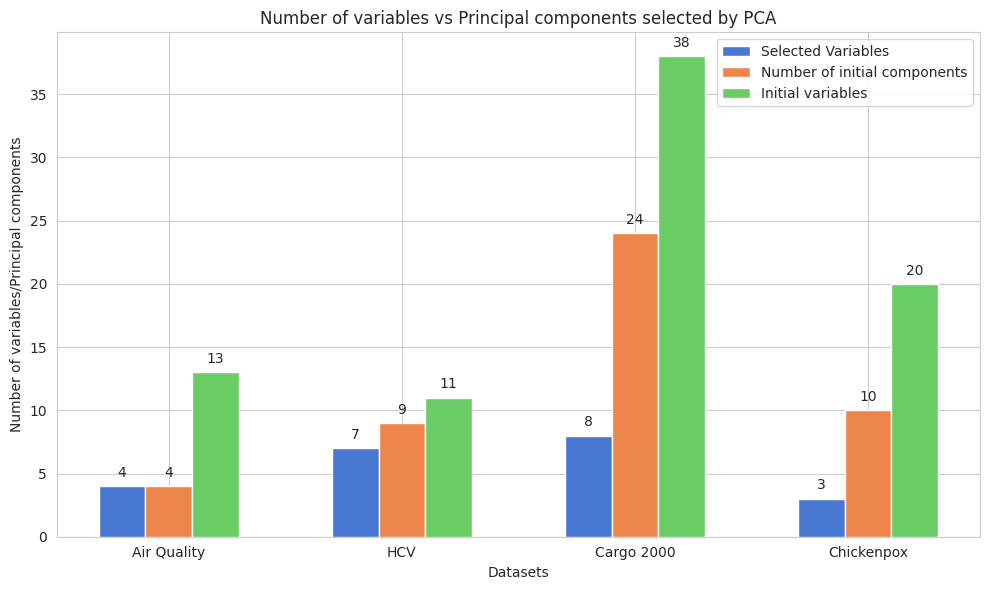

In [239]:

datasets = ["Air Quality","HCV", "Cargo 2000", "Chickenpox"]
num_selected_features = [len(np.unique(result_df[0])), 7, len(result_df[2]), 3]
print(num_selected_features)
num_initial_components = [ n_components_Air,n_components_hcv, n_components_dfc, n_components_df4]
print(num_initial_components)
num_original_variables = [13, df2.shape[1], dfc.shape[1], df4.shape[1]]

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.2 
x = range(len(datasets))

# Barres pour chaque type de donnée
bars_selected = ax.bar([p - width for p in x], num_selected_features, width=width, label="Selected Variables")
bars_components = ax.bar(x, num_initial_components, width=width, label="Number of initial components")
bars_original = ax.bar([p + width for p in x], num_original_variables, width=width, label="Initial variables")

# Ajouter les valeurs au-dessus de chaque barre
for bars in [bars_selected, bars_components, bars_original]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, int(yval), ha='center', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_xlabel("Datasets")
ax.set_ylabel("Number of variables/Principal components")
ax.set_title("Number of variables vs Principal components selected by PCA")
ax.legend()

plt.savefig("../images_conf/variablesComposantesEN.eps", format="eps", dpi=300)
plt.tight_layout()
plt.show()


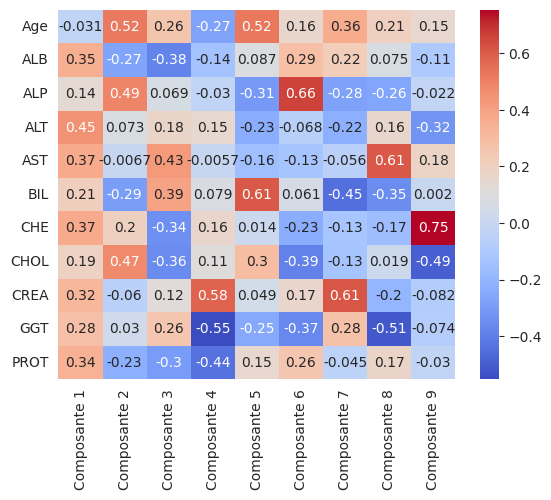

In [240]:
sns.heatmap(importance_features_hcv, cmap='coolwarm', annot=True)
plt.show()

In [241]:
#df1[list(set(result_df[0]))].to_csv("../data/AfterPCA/Air_quality.csv", index=False)
#df2[list(set(result_df[1]))].to_csv("../data/AfterPCA/HCV.csv", index=False)
#dfc[list(set(result_df[2]))].to_csv("../data/AfterPCA/Cargo_2000.csv", index=False)
#df4[list(set(result_df[3]))].to_csv("../data/AfterPCA/Chickenpox.csv", index=False)


In [242]:
result_df[2]

['legs',
 'i2_dep_1_place',
 'i1_legid',
 'o_dlv_e',
 'i2_dlv_e',
 'o_rcf_1_place',
 'o_dep_1_e',
 'i1_dlv_e']

In [243]:
print(len(result_df[0]))
print(len(set(result_df[0])))

4
4


In [244]:
print(len(result_df[1]))
print(len(set(result_df[1])))

10
7


In [245]:
print(len(result_df[2]))
print(len(set(result_df[2])))

8
8


In [246]:
print(len(result_df[3]))
print(len(set(result_df[3])))

4
3


In [247]:
#df1.to_csv('../data/Air_quality.csv', index=False)

In [248]:
#df2.to_csv('../data/HCV.csv', index=False)

In [249]:
#dfc.to_csv('../data/Cargo_2000.csv', index=False)

In [250]:
#df4.to_csv('../data/Chickenpox.csv', index=False)

In [251]:
#plot_pca_variance([df1, df2, df4, dfc])